In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

In [62]:
def categorical_feature_analysis(df, var_name):
    # Analyze the feature #var_name
    print(f'Category counts for {var_name}:\n{df[var_name].value_counts(dropna=False)}\n') #total feature values by category
    print(f'Category percentages for {var_name}:\n{df[var_name].value_counts(normalize=True, dropna=False)}\n') #percentage of total feature values by category
    print(f'Number of unique categories for {var_name}: {len(df[var_name].unique())}\n') #feature's unique values

def continuous_feature_analysis(df, var_name):
    # Analyze the feature #var_name
    #print(f'Distribution of data values of feature {var_name}:\n{df[var_name].value_counts(dropna=False)}\n') #distribution of feature values
    #print(f'Percentage of data distribution of feature {var_name}:\n{df[var_name].value_counts(normalize=True, dropna=False)}\n') #percentage of distribution of feature values
    print(f'Total unique values of feature {var_name}: {len(df[var_name].unique())}\n') #feature's unique values
    display(df[var_name].describe())

In [ ]:
from pathlib import Path

columns_path = Path("../src/data/census-bureau.columns")
with open(columns_path, "r") as f:
    columns = [line.strip() for line in f if line.strip()]

print(columns)
print(len(columns))

['age', 'class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'wage per hour', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'weight', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'weeks worked 

In [ ]:
data_path = Path("../src/data/census-bureau.data")

raw_data = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    skipinitialspace=True
)

print(raw_data.shape)
raw_data.head().transpose()


(199523, 42)


,0,1,2,3,4
age,73,58,18,9,10
class of worker,Not in universe,Self-employed-not incorporated,Not in universe,Not in universe,Not in universe
detailed industry recode,0,4,0,0,0
detailed occupation recode,0,34,0,0,0
education,High school graduate,Some college but no degree,10th grade,Children,Children
wage per hour,0,0,0,0,0
enroll in edu inst last wk,Not in universe,Not in universe,High school,Not in universe,Not in universe
marital stat,Widowed,Divorced,Never married,Never married,Never married
major industry code,Not in universe or children,Construction,Not in universe or children,Not in universe or children,Not in universe or children
major occupation code,Not in universe,Precision production craft & repair,Not in universe,Not in universe,Not in universe


In [16]:
raw_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  object 
 2   detailed industry recode                    199523 non-null  int64  
 3   detailed occupation recode                  199523 non-null  int64  
 4   education                                   199523 non-null  object 
 5   wage per hour                               199523 non-null  int64  
 6   enroll in edu inst last wk                  199523 non-null  object 
 7   marital stat                                199523 non-null  object 
 8   major industry code                         199523 non-null  object 
 9   major occupation code                       199523 non-null  object 
 

## only column 11 hispanic origin has less than 199523 non-null dtype

In [7]:
# check duplicates
duplicate_rows = raw_data.duplicated(keep='first')
print(f'number of duplicates = {duplicate_rows.sum()}')

# remove duplicates
raw_data = raw_data.drop_duplicates(keep="first")
print(f'number of remaining rows = {len(raw_data)}')

number of duplicates = 3229
number of remaining rows = 196294


In [8]:
raw_data.isnull().any()
raw_data["hispanic origin"].isna().sum()

870

In [9]:
raw_data["hispanic origin"] = raw_data["hispanic origin"].fillna("?")
raw_data["hispanic origin"].isna().sum()

0

In [10]:
# map the values in the label column from '50000+.' to 1 and 0 otherwise.
# map the values in the sex column from Male/Female to 1/0

raw_data['label'] = raw_data["label"].map(
    lambda x: '>$50,000' if str(x).strip() == '50000+.' else '<$50,000')

In [ ]:
raw_data["sex"] = raw_data["sex"].map(
    lambda x: 1 if str(x).strip() == "Male" else 0)
print(raw_data['sex'].sum())

In [11]:
non_int_cols = raw_data.select_dtypes(exclude=["number"]).columns
print(non_int_cols)
print(len(non_int_cols))

for col in non_int_cols:
    print(f"\n===== {col} =====")
    print(raw_data[col].unique())

Index(['class of worker', 'education', 'enroll in edu inst last wk',
       'marital stat', 'major industry code', 'major occupation code', 'race',
       'hispanic origin', 'sex', 'member of a labor union',
       'reason for unemployment', 'full or part time employment stat',
       'tax filer stat', 'region of previous residence',
       'state of previous residence', 'detailed household and family stat',
       'detailed household summary in household',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'family members under 18',
       'country of birth father', 'country of birth mother',
       'country of birth self', 'citizenship',
       'fill inc questionnaire for veteran's admin', 'label'],
      dtype='object')
29

===== class of worker =====
['Not in universe' 'Self-employed-not incorporated' 'Private'
 'Local government' 'Federal government

# 12 value column, 28 categorical column, 19 categorical column with unknown value

# Part 2: EDA

# Feature Label

Category counts for label:
label
<$50,000    183912
>$50,000     12382
Name: count, dtype: int64

Category percentages for label:
label
<$50,000    0.936921
>$50,000    0.063079
Name: proportion, dtype: float64

Unique categories for label:
['<$50,000' '>$50,000']



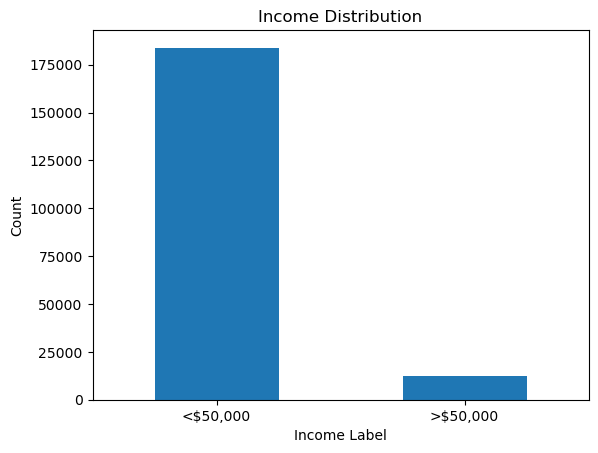

In [54]:
var = 'label'
categorical_feature_analysis(raw_data, var)

## plot distribution
raw_data[var].value_counts().plot(kind="bar")
plt.title("Income Distribution")
plt.xlabel("Income Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Continuous Value

In [49]:
def plot_continuous_by_label(
    df,
    var_name,
    target='label',
    bins=60,
    kde_line=True,
    subset_positive=False,
    upper_limit=None
):
    """
    Plot the distribution of a continuous feature by income label.

    Parameters:
    df : DataFrame
        The dataset.
    var_name : str
        Continuous column to analyze.
    target : str
        Label column.
    bins : int
        Number of histogram bins.
    subset_positive : bool
        If True, only plot rows where var_name > 0.
        Useful for wage, capital gains, capital losses, dividends, etc.
    upper_limit : int or float, optional
        If provided, only plot rows where var_name < upper_limit.
        Useful for reducing the effect of extreme outliers.
    """

    plot_df = df[[var_name, target]].copy()

    if subset_positive:
        plot_df = plot_df[plot_df[var_name] > 0]

    if upper_limit is not None:
        plot_df = plot_df[plot_df[var_name] < upper_limit]

    plt.figure(figsize=(8, 5))

    if kde_line:
        sns.histplot(
            data=plot_df,
            x=var_name,
            hue=target,
            bins=bins,
            kde=True,
            stat="density",
            common_norm=False,
            alpha=0.4
        )
    else:
        sns.histplot(
            data=plot_df,
            x=var_name,
            hue=target,
            bins=bins,
            stat="density",
            common_norm=False,
            alpha=0.4
        )

    plt.title(f"{var_name.title()} Distribution by Income Group")
    plt.xlabel(var_name.title())
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))

    if upper_limit:
        plot_df = df[[var_name, target]].copy()
        
    sns.boxplot(
        data=plot_df,
        x=target,
        y=var_name,
        hue=target
    )

    plt.title(f"{var_name.title()} by Income Group")
    plt.xlabel(target.title())
    plt.ylabel(var_name.title())
    plt.tight_layout()
    plt.show()

Total unique values of feature age: 91



count    196294.000000
mean         34.929468
std          22.210001
min           0.000000
25%          16.000000
50%          34.000000
75%          50.000000
max          90.000000
Name: age, dtype: float64

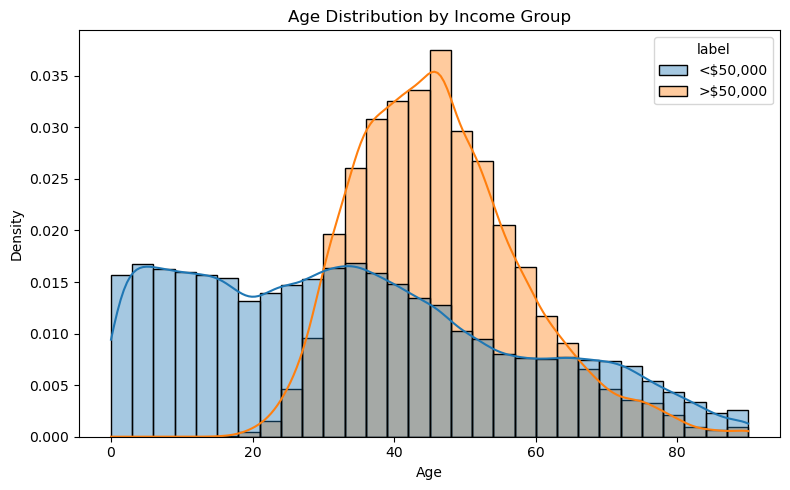

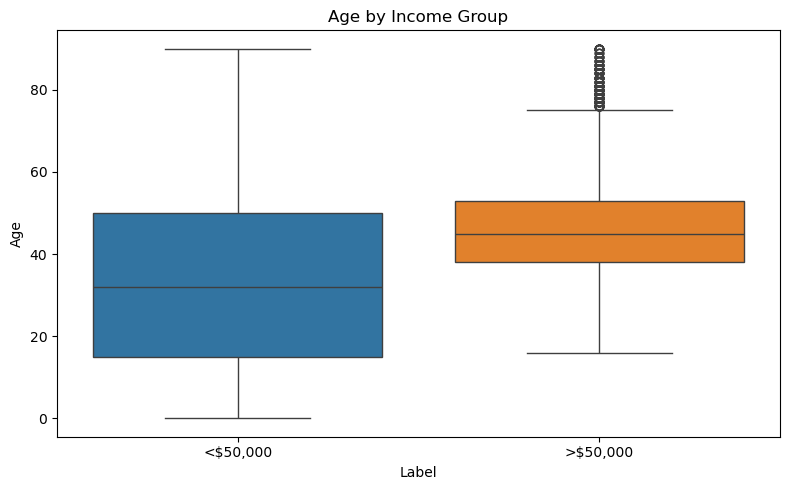

In [31]:
var = 'age'
continuous_feature_analysis(raw_data, var)
plot_continuous_by_label(raw_data, var, bins=30)

Total unique values of feature wage per hour: 1240



count    196294.000000
mean         56.336505
std         277.054333
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        9999.000000
Name: wage per hour, dtype: float64

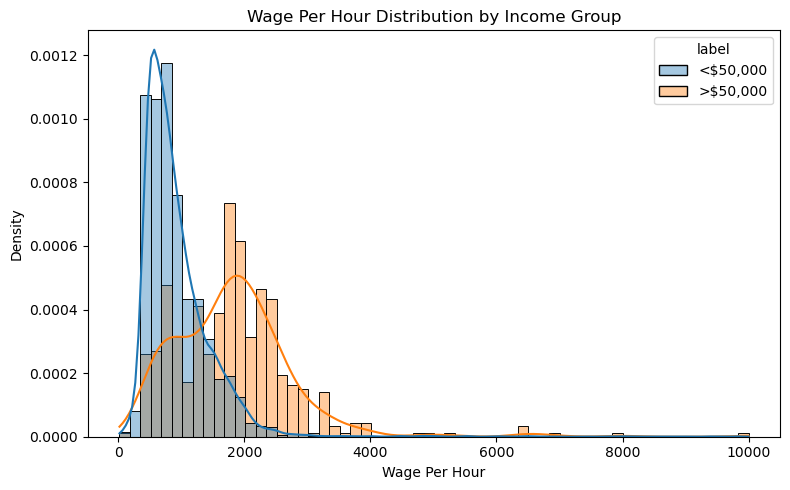

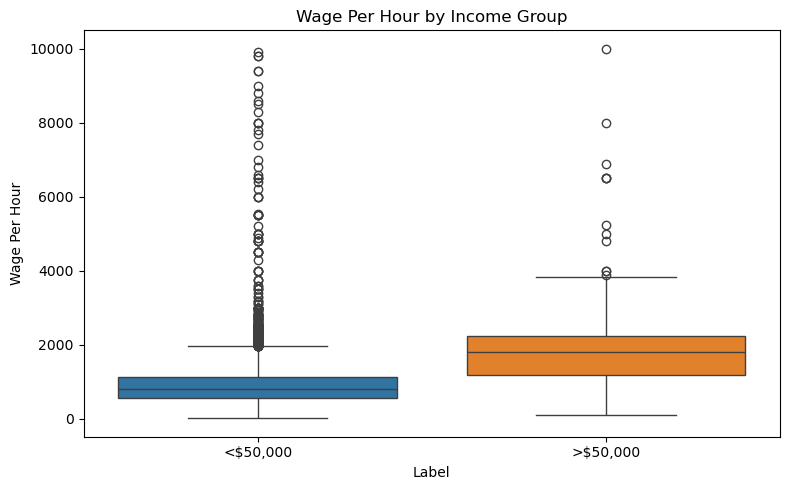

In [50]:
var = 'wage per hour'
continuous_feature_analysis(raw_data, var)
plot_continuous_by_label(raw_data, var, bins=60, subset_positive=True)

Total unique values of feature capital gains: 132



count    196294.000000
mean        441.870037
std        4735.677027
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       99999.000000
Name: capital gains, dtype: float64

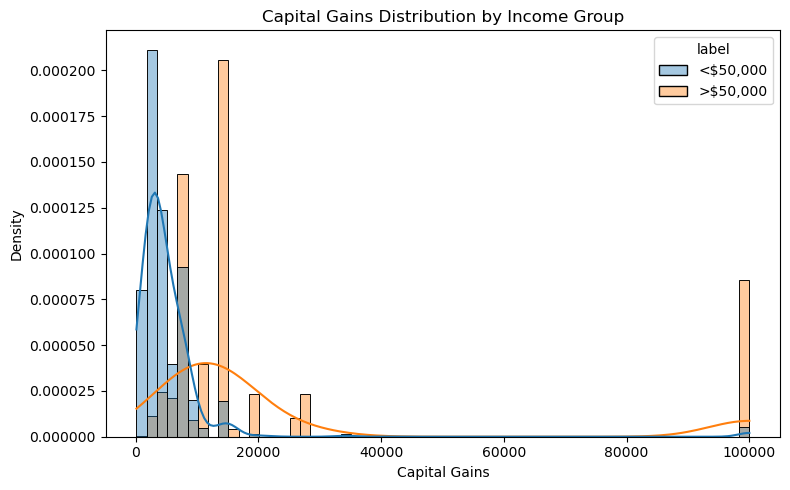

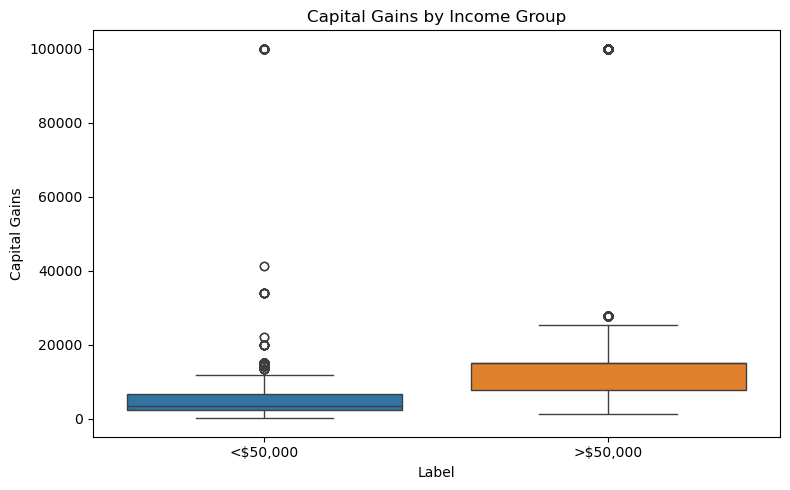

In [26]:
var = 'capital gains'
continuous_feature_analysis(raw_data, var)
plot_continuous_by_label(
    raw_data,
    var,
    bins=60,
    subset_positive=True
)

Total unique values of feature capital losses: 113



count    196294.000000
mean         37.927593
std         274.081174
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4608.000000
Name: capital losses, dtype: float64

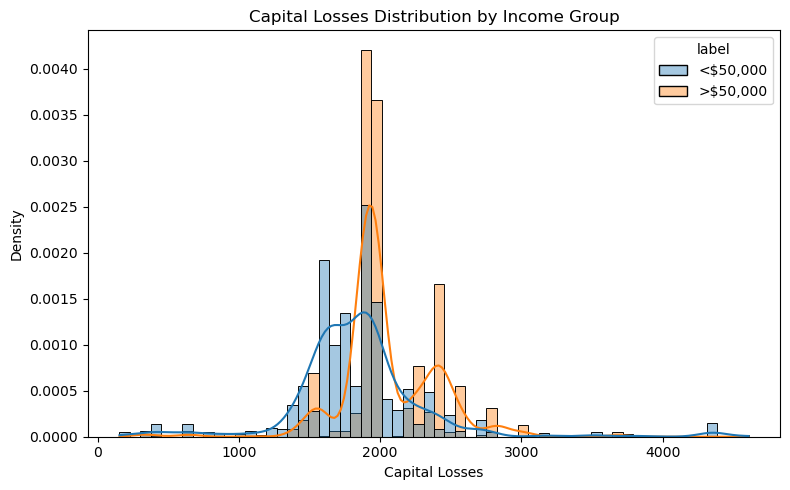

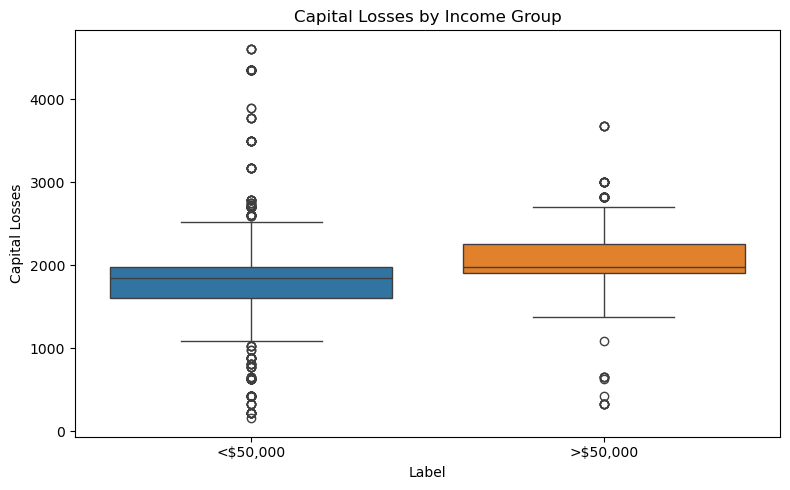

In [27]:
var = 'capital losses'
continuous_feature_analysis(raw_data, var)
plot_continuous_by_label(
    raw_data,
    var,
    bins=60,
    subset_positive=True
)

Total unique values of feature dividends from stocks: 1478



count    196294.000000
mean        200.722386
std        2000.130616
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       99999.000000
Name: dividends from stocks, dtype: float64

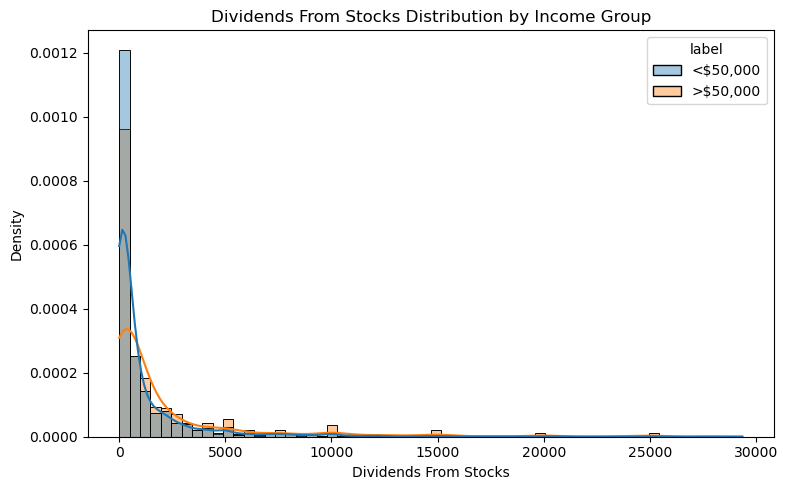

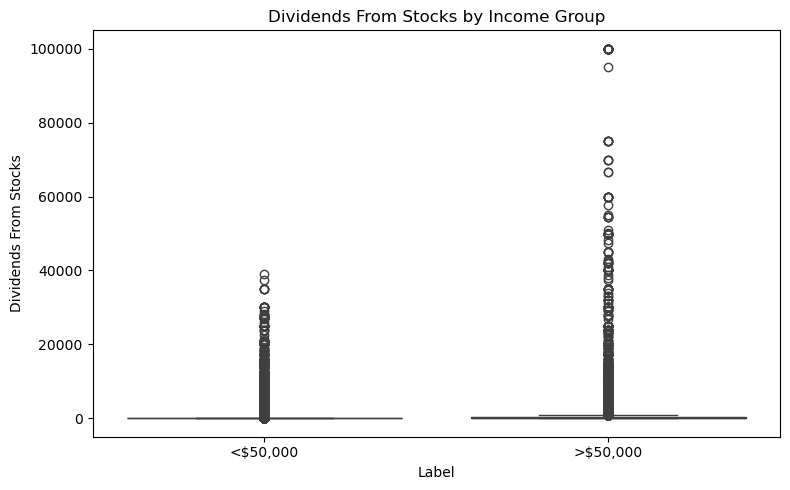

In [33]:
var = 'dividends from stocks'
continuous_feature_analysis(raw_data, var)
plot_continuous_by_label(
    raw_data,
    var,
    bins=60,
    subset_positive=True,
    upper_limit=30000
)

Total unique values of feature weeks worked in year: 53



count    196294.000000
mean         23.553889
std          24.428588
min           0.000000
25%           0.000000
50%          12.000000
75%          52.000000
max          52.000000
Name: weeks worked in year, dtype: float64

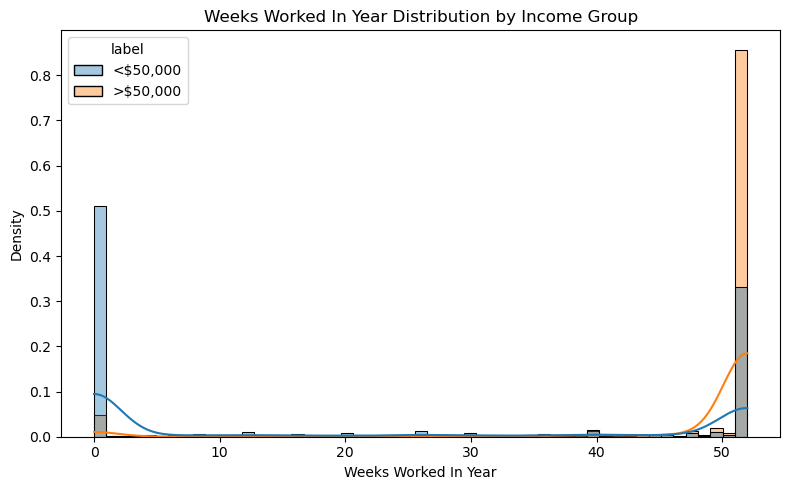

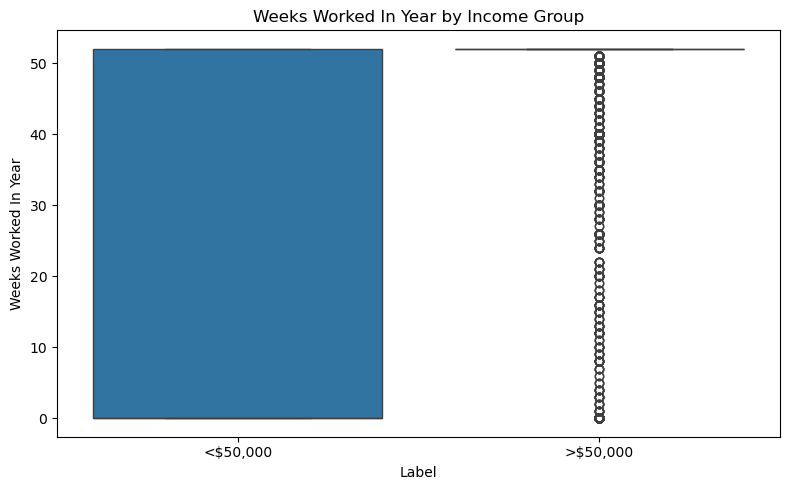

In [34]:
var = 'weeks worked in year'
continuous_feature_analysis(raw_data, var)
plot_continuous_by_label(
    raw_data,
    var,
    bins=53,
)

# Numeric columns - discrete/count features

In [45]:
def plot_numeric_bar_by_label(df, var_name, target='label'):
    """
    Plot a numeric/discrete feature as normalized bar charts by income label.

    Best for numeric columns with a small number of unique values, such as:
    - num persons worked for employer
    - own business or self employed
    - veterans benefits
    - year
    """

    ct = pd.crosstab(
        df[var_name],
        df[target],
        normalize='columns'
    )

    ax = ct.plot(
        kind='bar',
        figsize=(8, 5),
        edgecolor='black'
    )

    ax.set_title(f'{var_name.title()} Distribution by Income Group')
    ax.set_xlabel(var_name.title())
    ax.set_ylabel('Proportion Within Income Group')
    ax.legend(title=target.title())

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df[[var_name, target]],
        x=target,
        y=var_name,
        hue=target
    )

    plt.title(f"{var_name.title()} by Income Group")
    plt.xlabel(target.title())
    plt.ylabel(var_name.title())
    plt.tight_layout()
    plt.show()

    display(ct)

Total unique values of feature num persons worked for employer: 7



count    196294.000000
mean          1.988105
std           2.371018
min           0.000000
25%           0.000000
50%           1.000000
75%           4.000000
max           6.000000
Name: num persons worked for employer, dtype: float64

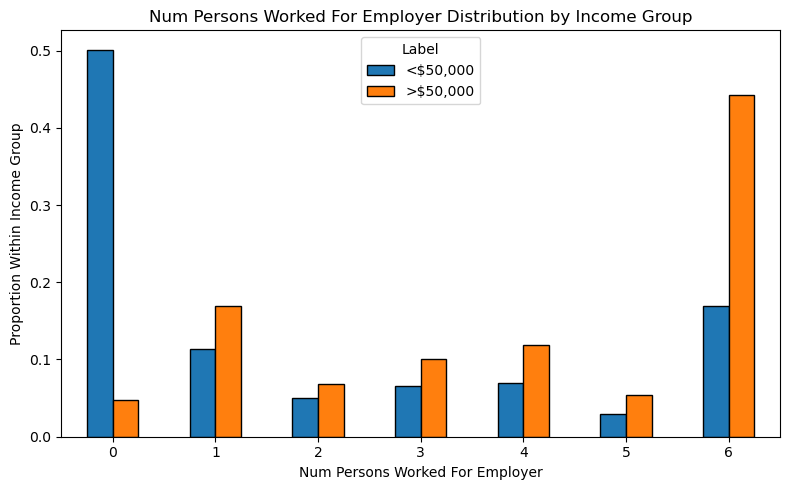

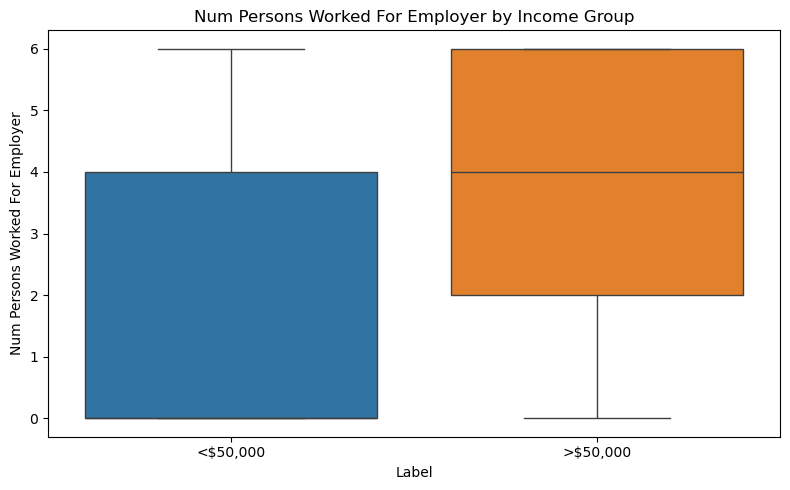

label,"<$50,000",">$50,000"
num persons worked for employer,,
0,0.501185,0.048134
1,0.114239,0.169036
2,0.050247,0.067679
3,0.066249,0.100145
4,0.070180,0.118721
5,0.029193,0.053707
6,0.168706,0.442578


In [46]:
var = 'num persons worked for employer'
continuous_feature_analysis(raw_data, var)
plot_numeric_bar_by_label(raw_data, var)

Category counts for detailed industry recode:
detailed industry recode
0     97467
33    17069
43     8283
4      5984
42     4683
45     4482
29     4209
37     4022
41     3964
32     3594
35     3380
39     2937
34     2765
44     2547
2      2194
11     1764
50     1704
40     1650
47     1644
38     1629
24     1503
12     1350
19     1345
30     1181
31     1178
25     1084
9       992
22      952
36      945
13      899
1       827
48      652
27      626
49      610
3       563
21      559
6       554
5       553
8       550
16      539
23      525
18      483
15      452
7       422
14      295
46      186
17      157
28      143
26      126
51       36
20       32
10        4
Name: count, dtype: int64

Category percentages for detailed industry recode:
detailed industry recode
0     0.496536
33    0.086956
43    0.042197
4     0.030485
42    0.023857
45    0.022833
29    0.021442
37    0.020490
41    0.020194
32    0.018309
35    0.017219
39    0.014962
34    0.014086
44    0

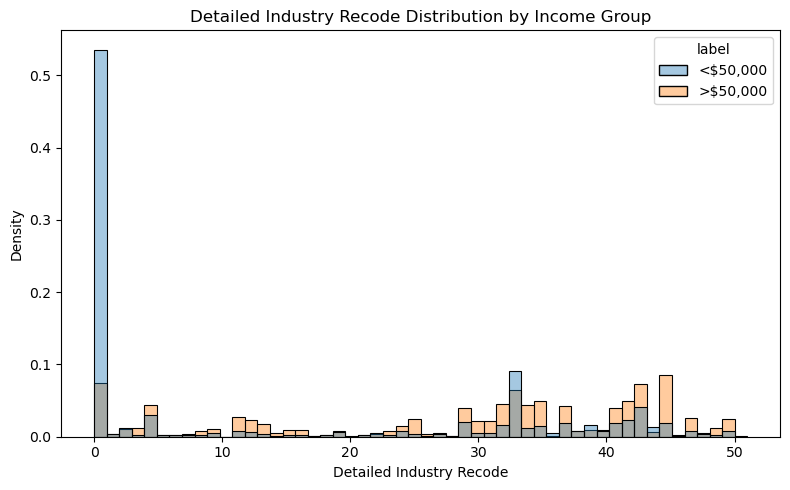

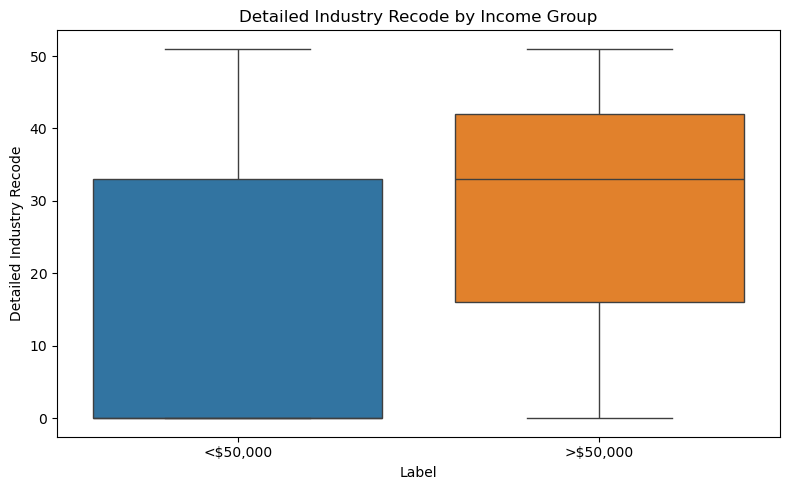

In [53]:
var = 'detailed industry recode'
categorical_feature_analysis(raw_data, var)
plot_continuous_by_label(
    raw_data,
    var,
    bins=len(raw_data[var].unique()),
    kde_line=False
)

Category counts for detailed occupation recode:
detailed occupation recode
0     97467
2      8756
26     7886
19     5412
29     5105
36     4144
34     4025
10     3683
16     3445
23     3392
12     3340
33     3325
3      3195
35     3167
38     3003
31     2699
32     2396
37     2233
8      2151
42     1917
30     1897
24     1847
17     1771
28     1661
41     1592
44     1592
43     1380
4      1364
13     1271
18     1082
39     1017
14      932
5       855
15      815
27      780
25      767
9       738
7       731
11      637
40      617
1       544
21      533
6       441
22      411
45      171
20       71
46       36
Name: count, dtype: int64

Category percentages for detailed occupation recode:
detailed occupation recode
0     0.496536
2     0.044607
26    0.040174
19    0.027571
29    0.026007
36    0.021111
34    0.020505
10    0.018763
16    0.017550
23    0.017280
12    0.017015
33    0.016939
3     0.016277
35    0.016134
38    0.015298
31    0.013750
32    0.012206

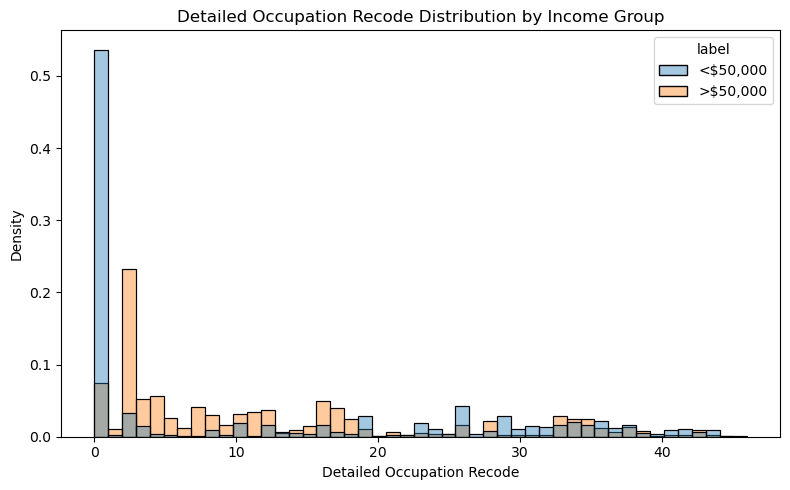

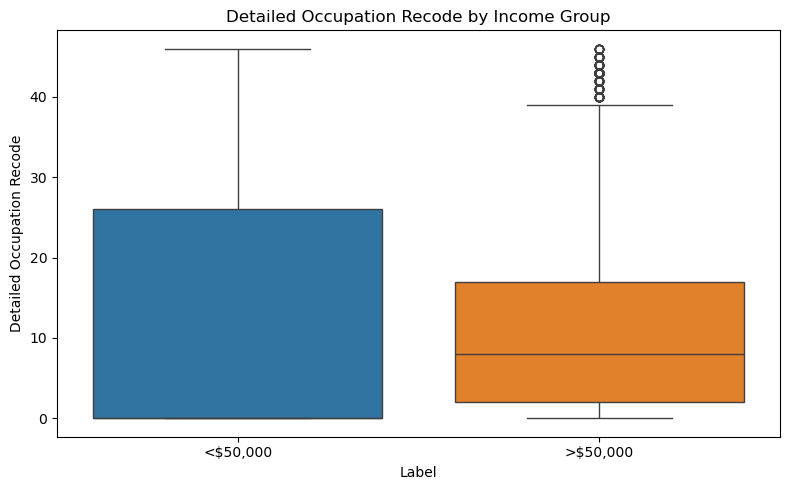

In [54]:
var = 'detailed occupation recode'
categorical_feature_analysis(raw_data, var)
plot_continuous_by_label(
    raw_data,
    var,
    bins=len(raw_data[var].unique()),
    kde_line=False
)

# categorical columns - all known classes

In [95]:
def plot_categorical_by_label(df, var_name, target='label', top_n=20):
    """Plot the distribution of a categorical feature within each income label."""
    value_counts = df[var_name].value_counts(dropna=False)
    top_categories = value_counts.head(top_n).index

    plot_df = df[[var_name, target]].copy()
    if len(value_counts) > top_n:
        plot_df[var_name] = np.where(
            plot_df[var_name].isin(top_categories),
            plot_df[var_name],
            'Other'
        )

    category_order = list(top_categories)
    if len(value_counts) > top_n:
        category_order.append('Other')

    ct = pd.crosstab(plot_df[var_name], plot_df[target], normalize='columns')
    ct = ct.reindex(category_order)

    ax = ct.plot(kind='bar', figsize=(10, 5), edgecolor='black')
    ax.set_title(f'{var_name.title()} Distribution by Income Group')
    ax.set_xlabel(var_name.title())
    ax.set_ylabel('Proportion Within Income Group')
    ax.legend(title=target.title())
    if len(value_counts) > 4:
        plt.xticks(rotation=45, ha='right')
    else:
        plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    display(ct)

Category counts for own business or self employed:
own business or self employed
0    177445
2     16151
1      2698
Name: count, dtype: int64

Category percentages for own business or self employed:
own business or self employed
0    0.903976
2    0.082280
1    0.013745
Name: proportion, dtype: float64

Number of unique categories for own business or self employed: 3



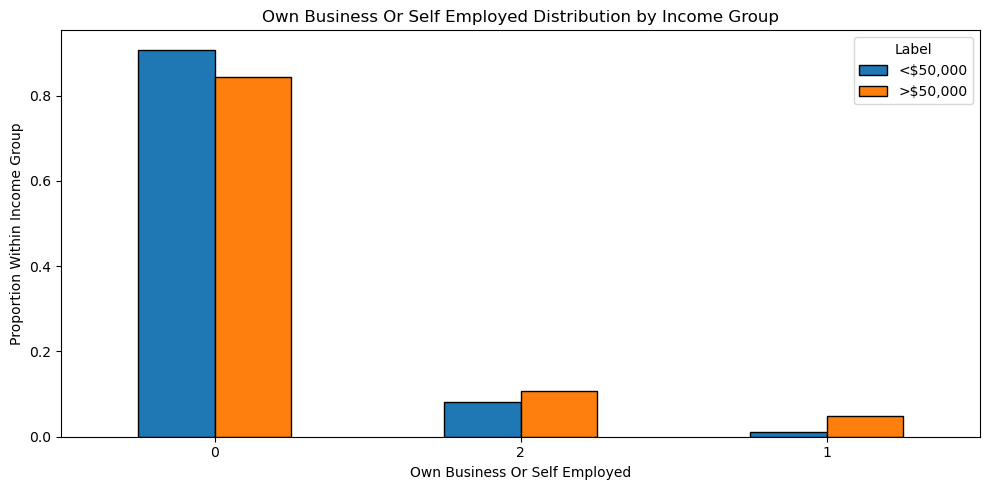

label,"<$50,000",">$50,000"
own business or self employed,,
0,0.908005,0.844129
2,0.080636,0.106687
1,0.011359,0.049184


In [63]:
var = 'own business or self employed'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)


Category counts for veterans benefits:
veterans benefits
2    149976
0     44334
1      1984
Name: count, dtype: int64

Category percentages for veterans benefits:
veterans benefits
2    0.764038
0    0.225855
1    0.010107
Name: proportion, dtype: float64

Number of unique categories for veterans benefits: 3



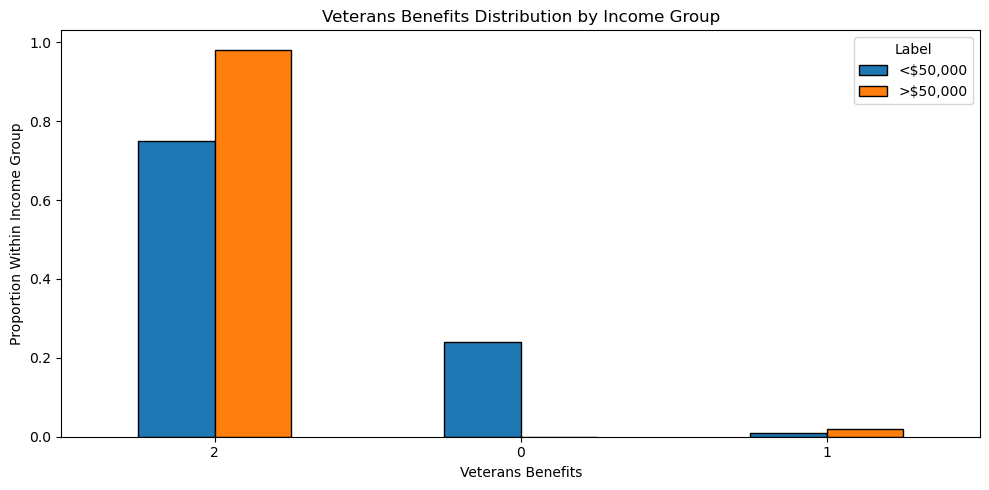

label,"<$50,000",">$50,000"
veterans benefits,,
2,0.749407,0.981344
0,0.241061,0.000000
1,0.009532,0.018656


In [64]:
var = 'veterans benefits'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)


Category counts for education:
education
High school graduate                      48374
Children                                  44347
Some college but no degree                27809
Bachelors degree(BA AB BS)                19859
7th and 8th grade                          7976
10th grade                                 7539
11th grade                                 6862
Masters degree(MA MS MEng MEd MSW MBA)     6540
9th grade                                  6193
Associates degree-occup /vocational        5358
Associates degree-academic program         4363
5th or 6th grade                           3277
12th grade no diploma                      2125
1st 2nd 3rd or 4th grade                   1799
Prof school degree (MD DDS DVM LLB JD)     1793
Doctorate degree(PhD EdD)                  1263
Less than 1st grade                         817
Name: count, dtype: int64

Category percentages for education:
education
High school graduate                      0.246436
Children           

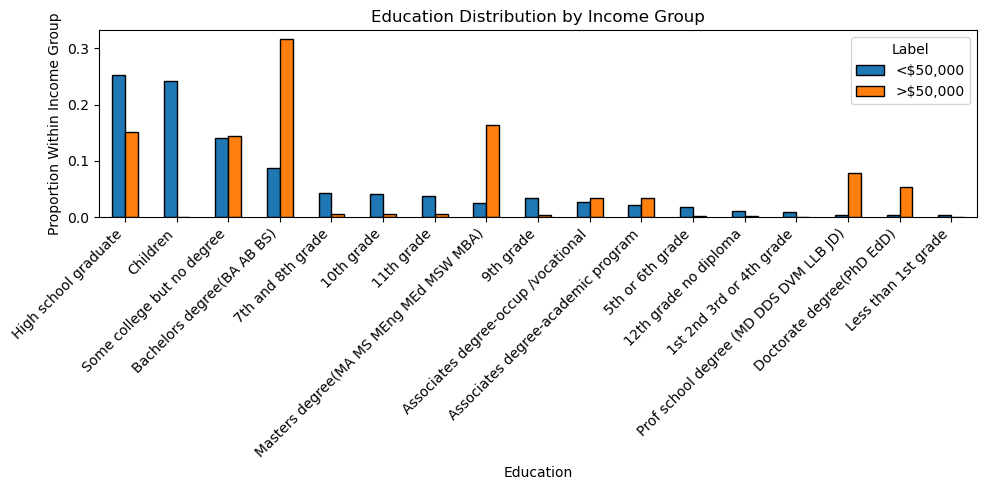

label,"<$50,000",">$50,000"
education,,
High school graduate,0.252811,0.151753
Children,0.241132,0.000000
Some college but no degree,0.141492,0.144322
Bachelors degree(BA AB BS),0.086694,0.316185
7th and 8th grade,0.042977,0.005815
10th grade,0.040655,0.005007
11th grade,0.036931,0.005653
Masters degree(MA MS MEng MEd MSW MBA),0.024479,0.164594
9th grade,0.033467,0.003069


In [102]:
var = 'education'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for marital stat:
marital stat
Married-civilian spouse present    84194
Never married                      83296
Divorced                           12707
Widowed                            10456
Separated                           3459
Married-spouse absent               1517
Married-A F spouse present           665
Name: count, dtype: int64

Category percentages for marital stat:
marital stat
Married-civilian spouse present    0.428918
Never married                      0.424343
Divorced                           0.064735
Widowed                            0.053267
Separated                          0.017622
Married-spouse absent              0.007728
Married-A F spouse present         0.003388
Name: proportion, dtype: float64

Number of unique categories for marital stat: 7



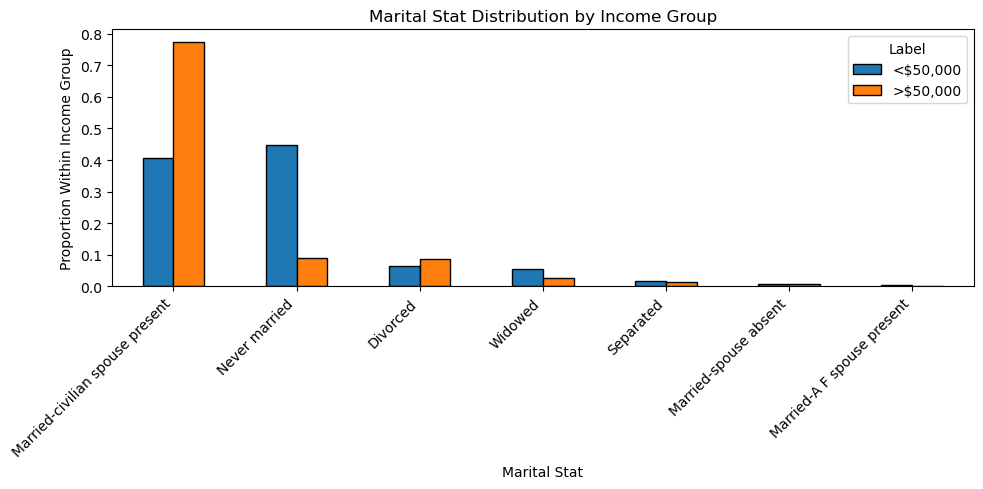

label,"<$50,000",">$50,000"
marital stat,,
Married-civilian spouse present,0.405596,0.775319
Never married,0.446839,0.090212
Divorced,0.063297,0.086093
Widowed,0.055059,0.026652
Separated,0.017949,0.012760
Married-spouse absent,0.007727,0.007753
Married-A F spouse present,0.003534,0.001211


In [106]:
var = 'marital stat'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for race:
race
White                          164380
Black                           20206
Asian or Pacific Islander        5821
Other                            3645
Amer Indian Aleut or Eskimo      2242
Name: count, dtype: int64

Category percentages for race:
race
White                          0.837417
Black                          0.102937
Asian or Pacific Islander      0.029654
Other                          0.018569
Amer Indian Aleut or Eskimo    0.011422
Name: proportion, dtype: float64

Number of unique categories for race: 5



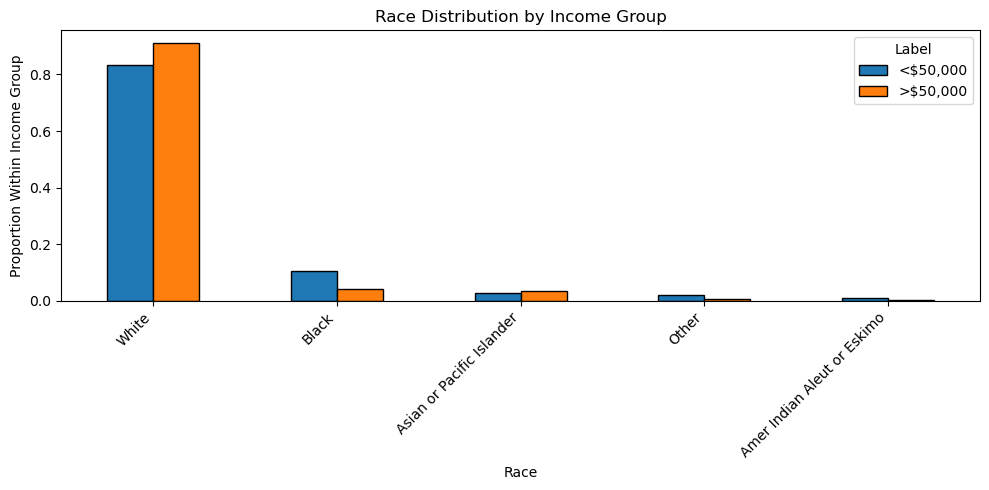

label,"<$50,000",">$50,000"
race,,
White,0.832507,0.910354
Black,0.106932,0.043612
Asian or Pacific Islander,0.029313,0.034728
Other,0.019324,0.007349
Amer Indian Aleut or Eskimo,0.011924,0.003957


In [107]:
var = 'race'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for sex:
sex
Female    102400
Male       93894
Name: count, dtype: int64

Category percentages for sex:
sex
Female    0.521666
Male      0.478334
Name: proportion, dtype: float64

Number of unique categories for sex: 2



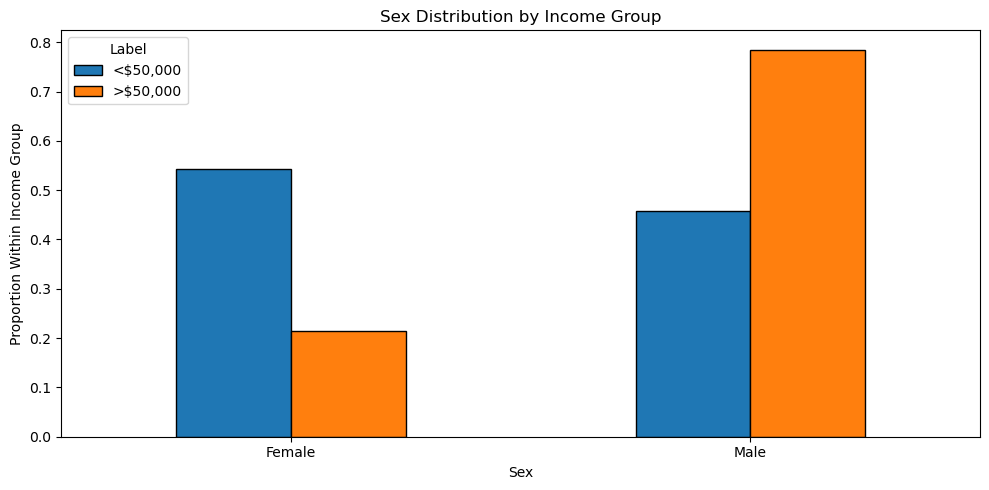

label,"<$50,000",">$50,000"
sex,,
Female,0.542308,0.21507
Male,0.457692,0.78493


In [108]:
var = 'sex'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for full or part time employment stat:
full or part time employment stat
Children or Armed Forces              120632
Full-time schedules                    40728
Not in labor force                     26726
PT for non-econ reasons usually FT      3322
Unemployed full-time                    2310
PT for econ reasons usually PT          1209
Unemployed part- time                    842
PT for econ reasons usually FT           525
Name: count, dtype: int64

Category percentages for full or part time employment stat:
full or part time employment stat
Children or Armed Forces              0.614548
Full-time schedules                   0.207485
Not in labor force                    0.136153
PT for non-econ reasons usually FT    0.016924
Unemployed full-time                  0.011768
PT for econ reasons usually PT        0.006159
Unemployed part- time                 0.004289
PT for econ reasons usually FT        0.002675
Name: proportion, dtype: float64

Number of unique cat

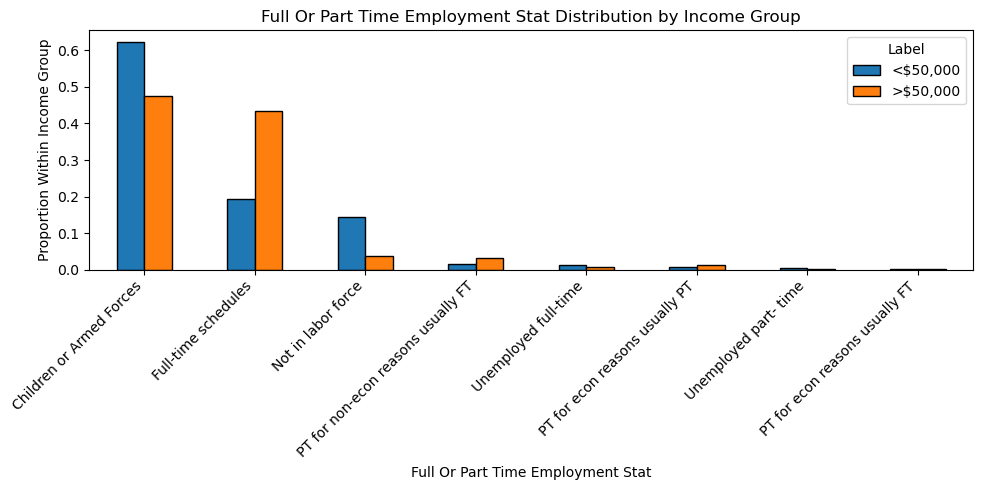

label,"<$50,000",">$50,000"
full or part time employment stat,,
Children or Armed Forces,0.623983,0.474398
Full-time schedules,0.192277,0.433371
Not in labor force,0.142807,0.037312
PT for non-econ reasons usually FT,0.015926,0.031740
Unemployed full-time,0.012109,0.006703
PT for econ reasons usually PT,0.005731,0.012518
Unemployed part- time,0.004480,0.001454
PT for econ reasons usually FT,0.002686,0.002504


In [109]:
var = 'full or part time employment stat'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for tax filer stat:
tax filer stat
Nonfiler                        71903
Joint both under 65             67367
Single                          37409
Joint both 65+                   8326
Head of household                7425
Joint one under 65 & one 65+     3864
Name: count, dtype: int64

Category percentages for tax filer stat:
tax filer stat
Nonfiler                        0.366303
Joint both under 65             0.343194
Single                          0.190576
Joint both 65+                  0.042416
Head of household               0.037826
Joint one under 65 & one 65+    0.019685
Name: proportion, dtype: float64

Number of unique categories for tax filer stat: 6



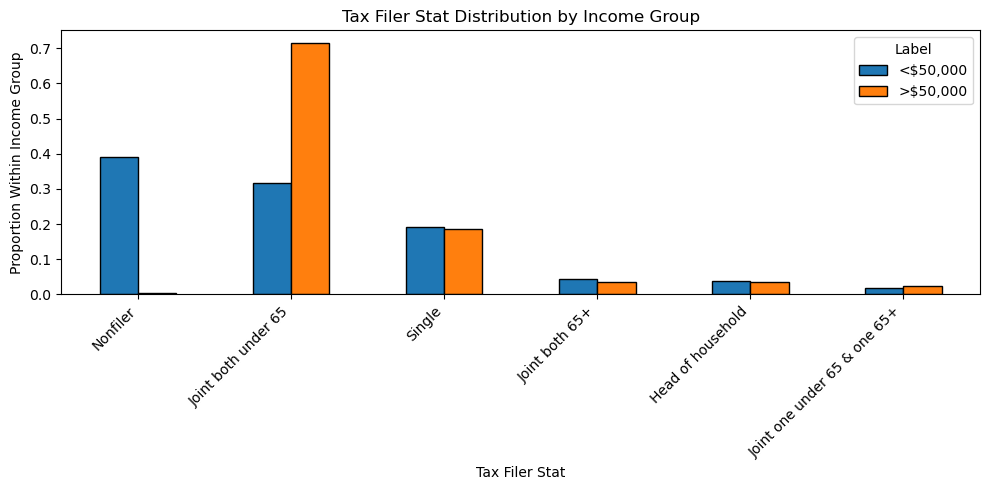

label,"<$50,000",">$50,000"
tax filer stat,,
Nonfiler,0.390774,0.002827
Joint both under 65,0.318163,0.714990
Single,0.190928,0.185350
Joint both 65+,0.042825,0.036343
Head of household,0.037937,0.036182
Joint one under 65 & one 65+,0.019373,0.024309


In [110]:
var = 'tax filer stat'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for detailed household and family stat:
detailed household and family stat
Householder                                        53242
Child <18 never marr not in subfamily              47219
Spouse of householder                              41670
Nonfamily householder                              22205
Child 18+ never marr Not in a subfamily            12016
Secondary individual                                6109
Other Rel 18+ ever marr not in subfamily            1953
Grandchild <18 never marr child of subfamily RP     1839
Other Rel 18+ never marr not in subfamily           1726
Grandchild <18 never marr not in subfamily          1055
Child 18+ ever marr Not in a subfamily              1013
Child under 18 of RP of unrel subfamily              729
RP of unrelated subfamily                            685
Child 18+ ever marr RP of subfamily                  671
Other Rel 18+ ever marr RP of subfamily              656
Other Rel <18 never marr child of subfamily RP       6

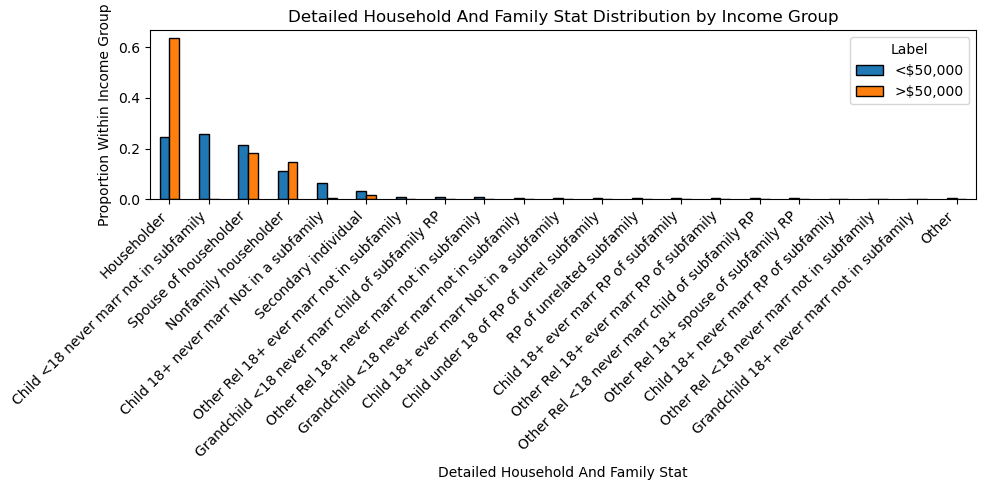

label,"<$50,000",">$50,000"
detailed household and family stat,,
Householder,0.246814,0.633985
Child <18 never marr not in subfamily,0.256737,0.000162
Spouse of householder,0.214168,0.184300
Nonfamily householder,0.110950,0.145372
Child 18+ never marr Not in a subfamily,0.064863,0.007026
Secondary individual,0.032021,0.017768
Other Rel 18+ ever marr not in subfamily,0.010521,0.001454
Grandchild <18 never marr child of subfamily RP,0.009999,0.000000
Other Rel 18+ never marr not in subfamily,0.009265,0.001777


In [111]:
var = 'detailed household and family stat'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for detailed household summary in household:
detailed household summary in household
Householder                             75461
Child under 18 never married            47318
Spouse of householder                   41684
Child 18 or older                       14416
Other relative of householder            9651
Nonrelative of householder               7585
Group Quarters- Secondary individual      132
Child under 18 ever married                47
Name: count, dtype: int64

Category percentages for detailed household summary in household:
detailed household summary in household
Householder                             0.384428
Child under 18 never married            0.241057
Spouse of householder                   0.212355
Child 18 or older                       0.073441
Other relative of householder           0.049166
Nonrelative of householder              0.038641
Group Quarters- Secondary individual    0.000672
Child under 18 ever married             0.000239
Name: 

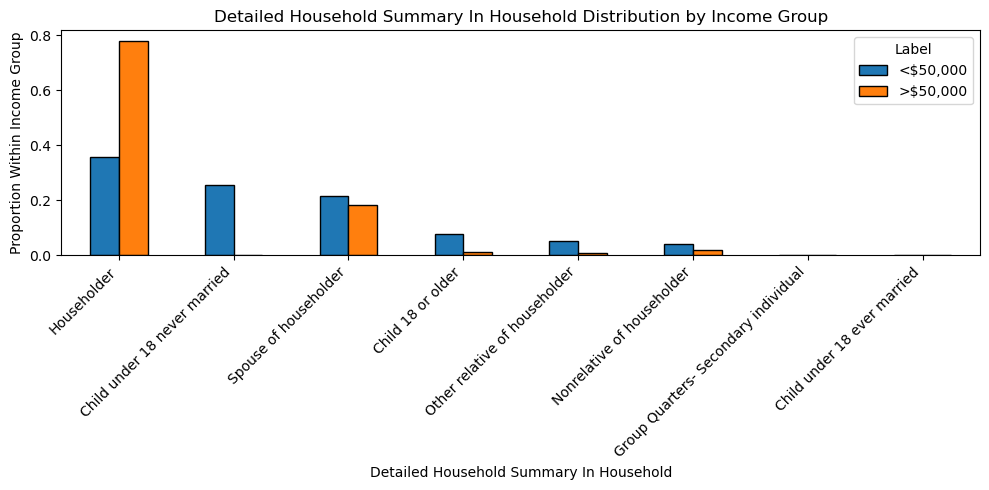

label,"<$50,000",">$50,000"
detailed household summary in household,,
Householder,0.357834,0.779438
Child under 18 never married,0.257275,0.000162
Spouse of householder,0.214244,0.184300
Child 18 or older,0.077700,0.010176
Other relative of householder,0.052009,0.006946
Nonrelative of householder,0.039970,0.018898
Group Quarters- Secondary individual,0.000712,0.000081
Child under 18 ever married,0.000256,0.000000


In [112]:
var = 'detailed household summary in household'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for citizenship:
citizenship
Native- Born in the United States              173786
Foreign born- Not a citizen of U S              13385
Foreign born- U S citizen by naturalization      5851
Native- Born abroad of American Parent(s)        1753
Native- Born in Puerto Rico or U S Outlying      1519
Name: count, dtype: int64

Category percentages for citizenship:
citizenship
Native- Born in the United States              0.885335
Foreign born- Not a citizen of U S             0.068189
Foreign born- U S citizen by naturalization    0.029807
Native- Born abroad of American Parent(s)      0.008930
Native- Born in Puerto Rico or U S Outlying    0.007738
Name: proportion, dtype: float64

Number of unique categories for citizenship: 5



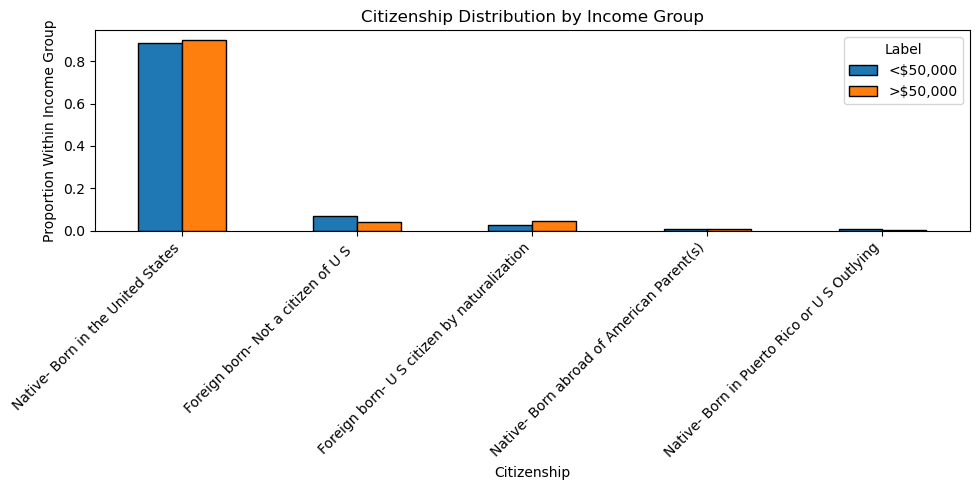

label,"<$50,000",">$50,000"
citizenship,,
Native- Born in the United States,0.884320,0.900420
Foreign born- Not a citizen of U S,0.070104,0.039735
Foreign born- U S citizen by naturalization,0.028660,0.046842
Native- Born abroad of American Parent(s),0.008836,0.010338
Native- Born in Puerto Rico or U S Outlying,0.008080,0.002665


In [113]:
var = 'citizenship'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for year:
year
94    98279
95    98015
Name: count, dtype: int64

Category percentages for year:
year
94    0.500672
95    0.499328
Name: proportion, dtype: float64

Number of unique categories for year: 2



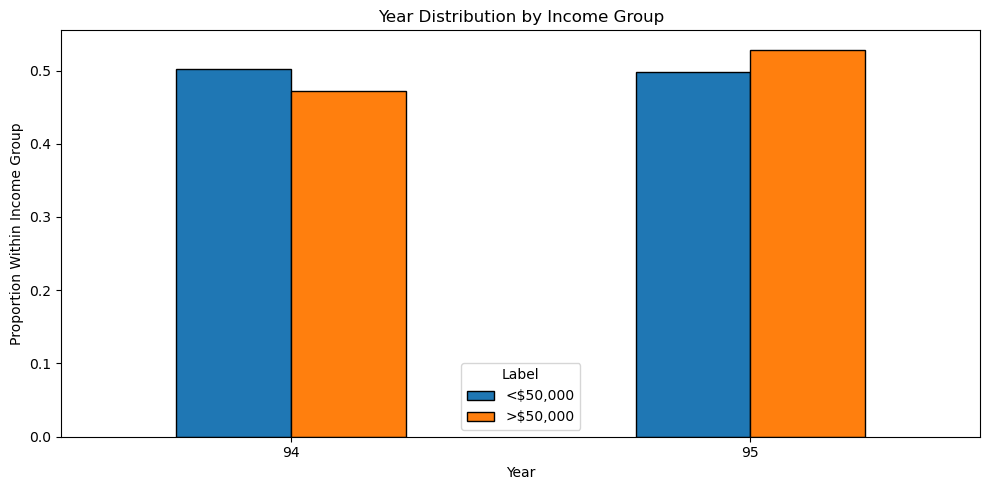

label,"<$50,000",">$50,000"
year,,
94,0.502632,0.471572
95,0.497368,0.528428


In [114]:
var = 'year'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

# categorical columns with Undefined or Missing Values

Category counts for class of worker:
class of worker
Not in universe                   97029
Private                           72021
Self-employed-not incorporated     8442
Local government                   7783
State government                   4227
Self-employed-incorporated         3264
Federal government                 2925
Never worked                        438
Without pay                         165
Name: count, dtype: int64

Category percentages for class of worker:
class of worker
Not in universe                   0.494304
Private                           0.366904
Self-employed-not incorporated    0.043007
Local government                  0.039650
State government                  0.021534
Self-employed-incorporated        0.016628
Federal government                0.014901
Never worked                      0.002231
Without pay                       0.000841
Name: proportion, dtype: float64

Number of unique categories for class of worker: 9



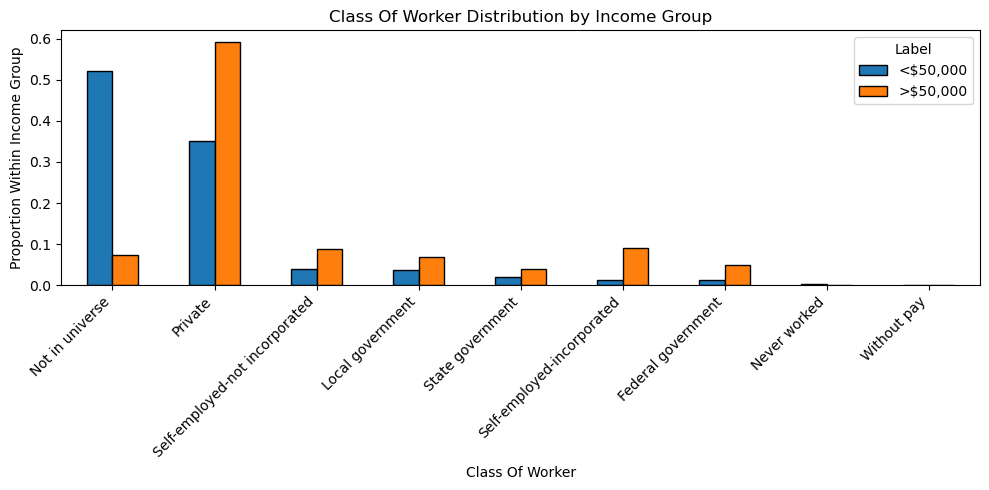

label,"<$50,000",">$50,000"
class of worker,,
Not in universe,0.522668,0.073009
Private,0.351793,0.591342
Self-employed-not incorporated,0.039976,0.088031
Local government,0.037714,0.068406
State government,0.020347,0.039170
Self-employed-incorporated,0.011582,0.091585
Federal government,0.012658,0.048215
Never worked,0.002371,0.000162
Without pay,0.000892,0.000081


In [65]:
var = 'class of worker'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for enroll in edu inst last wk:
enroll in edu inst last wk
Not in universe          183762
High school                6853
College or university      5679
Name: count, dtype: int64

Category percentages for enroll in edu inst last wk:
enroll in edu inst last wk
Not in universe          0.936157
High school              0.034912
College or university    0.028931
Name: proportion, dtype: float64

Number of unique categories for enroll in edu inst last wk: 3



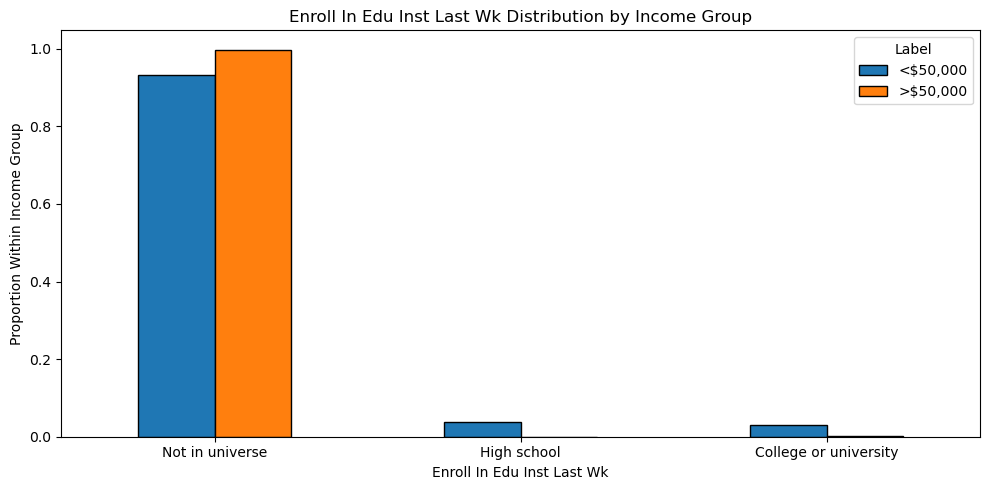

label,"<$50,000",">$50,000"
enroll in edu inst last wk,,
Not in universe,0.932022,0.997577
High school,0.037235,0.000404
College or university,0.030743,0.002019


In [67]:
var = 'enroll in edu inst last wk'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for major industry code:
major industry code
Not in universe or children            97467
Retail trade                           17069
Manufacturing-durable goods             9014
Education                               8283
Manufacturing-nondurable goods          6895
Finance insurance and real estate       6145
Construction                            5984
Business and repair services            5651
Medical except hospital                 4683
Public administration                   4610
Other professional services             4482
Transportation                          4209
Hospital services                       3964
Wholesale trade                         3594
Agriculture                             3021
Personal services except private HH     2937
Social services                         2547
Entertainment                           1650
Communications                          1181
Utilities and sanitary services         1178
Private household services             

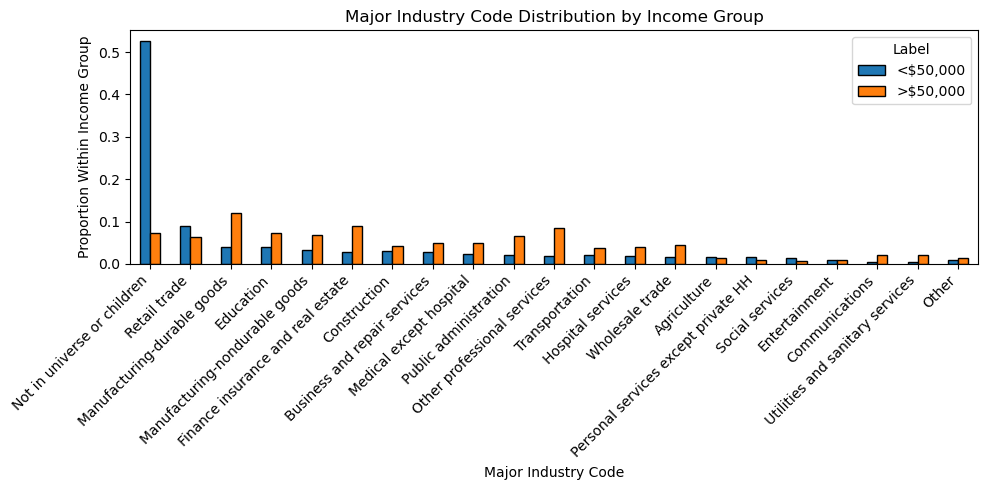

label,"<$50,000",">$50,000"
major industry code,,
Not in universe or children,0.525039,0.073171
Retail trade,0.088521,0.063722
Manufacturing-durable goods,0.040889,0.120659
Education,0.040193,0.071959
Manufacturing-nondurable goods,0.032836,0.069133
Finance insurance and real estate,0.027328,0.090373
Construction,0.029639,0.043046
Business and repair services,0.027361,0.049992
Medical except hospital,0.022201,0.048457


In [71]:
var = 'major industry code'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for major occupation code:
major occupation code
Not in universe                          97467
Adm support including clerical           14836
Professional specialty                   13940
Executive admin and managerial           12495
Other service                            12097
Sales                                    11781
Precision production craft & repair      10517
Machine operators assmblrs & inspctrs     6377
Handlers equip cleaners etc               4126
Transportation and material moving        4020
Farming forestry and fishing              3143
Technicians and related support           3018
Protective services                       1661
Private household services                 780
Armed Forces                                36
Name: count, dtype: int64

Category percentages for major occupation code:
major occupation code
Not in universe                          0.496536
Adm support including clerical           0.075581
Professional specialty           

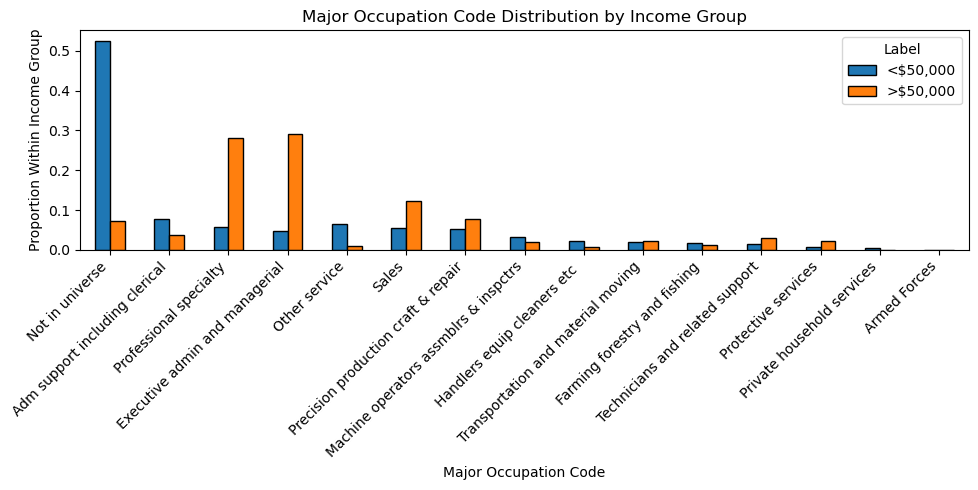

label,"<$50,000",">$50,000"
major occupation code,,
Not in universe,0.525039,0.073171
Adm support including clerical,0.078244,0.036020
Professional specialty,0.056902,0.280649
Executive admin and managerial,0.048404,0.290179
Other service,0.065124,0.009691
Sales,0.055771,0.123082
Precision production craft & repair,0.051992,0.077128
Machine operators assmblrs & inspctrs,0.033396,0.018979
Handlers equip cleaners etc,0.022005,0.006380


In [72]:
var = 'major occupation code'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for hispanic origin:
hispanic origin
All other                    168803
Mexican-American               8008
Mexican (Mexicano)             7210
Central or South American      3891
Puerto Rican                   3306
Other Spanish                  2476
Cuban                          1122
?                               870
Do not know                     305
Chicano                         303
Name: count, dtype: int64

Category percentages for hispanic origin:
hispanic origin
All other                    0.859950
Mexican-American             0.040796
Mexican (Mexicano)           0.036731
Central or South American    0.019822
Puerto Rican                 0.016842
Other Spanish                0.012614
Cuban                        0.005716
?                            0.004432
Do not know                  0.001554
Chicano                      0.001544
Name: proportion, dtype: float64

Number of unique categories for hispanic origin: 10



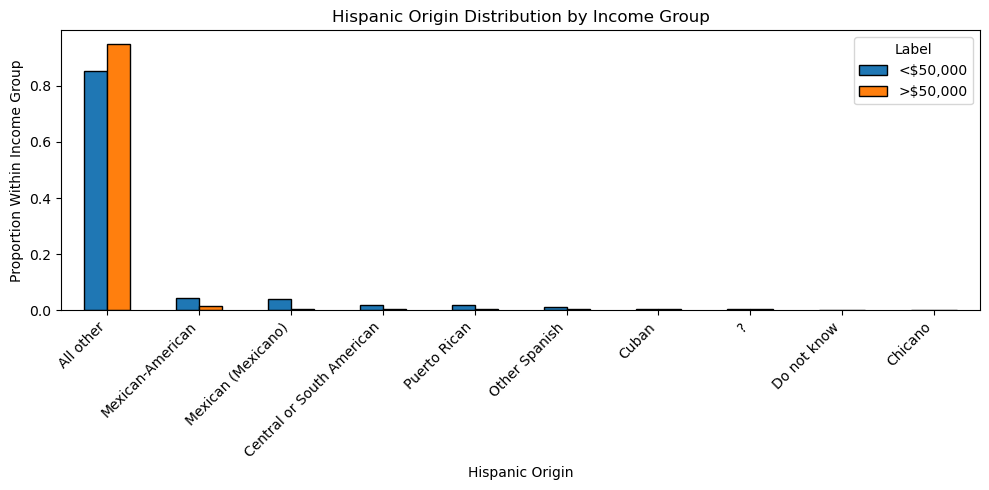

label,"<$50,000",">$50,000"
hispanic origin,,
All other,0.853865,0.950331
Mexican-American,0.042607,0.013891
Mexican (Mexicano),0.038758,0.006623
Central or South American,0.020722,0.006461
Puerto Rican,0.017606,0.005492
Other Spanish,0.013023,0.006542
Cuban,0.005769,0.004927
?,0.004421,0.004603
Do not know,0.001615,0.000646


In [74]:
var = 'hispanic origin'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for member of a labor union:
member of a labor union
Not in universe    177232
No                  16032
Yes                  3030
Name: count, dtype: int64

Category percentages for member of a labor union:
member of a labor union
Not in universe    0.902891
No                 0.081673
Yes                0.015436
Name: proportion, dtype: float64

Number of unique categories for member of a labor union: 3



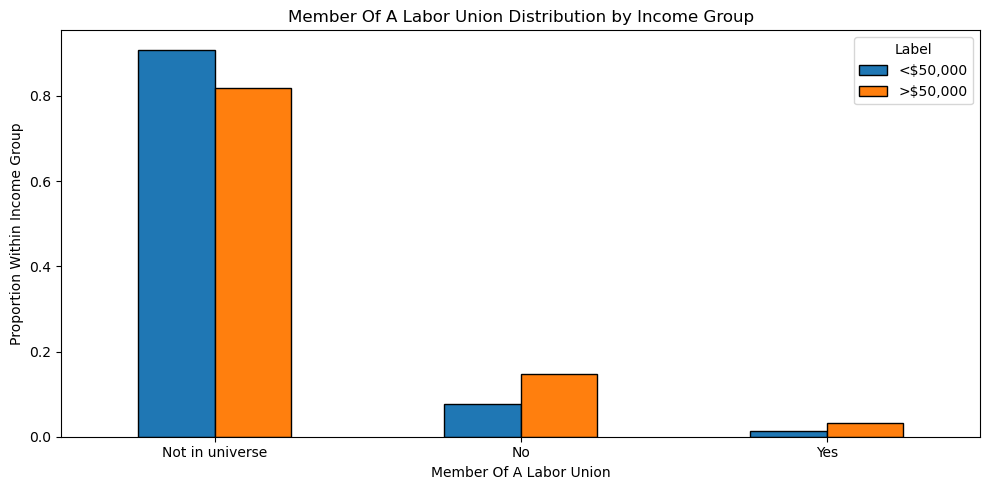

label,"<$50,000",">$50,000"
member of a labor union,,
Not in universe,0.908500,0.819577
No,0.077265,0.147149
Yes,0.014235,0.033274


In [76]:
var = 'member of a labor union'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for reason for unemployment:
reason for unemployment
Not in universe          190226
Other job loser            2038
Re-entrant                 2018
Job loser - on layoff       976
Job leaver                  598
New entrant                 438
Name: count, dtype: int64

Category percentages for reason for unemployment:
reason for unemployment
Not in universe          0.969087
Other job loser          0.010382
Re-entrant               0.010280
Job loser - on layoff    0.004972
Job leaver               0.003046
New entrant              0.002231
Name: proportion, dtype: float64

Number of unique categories for reason for unemployment: 6



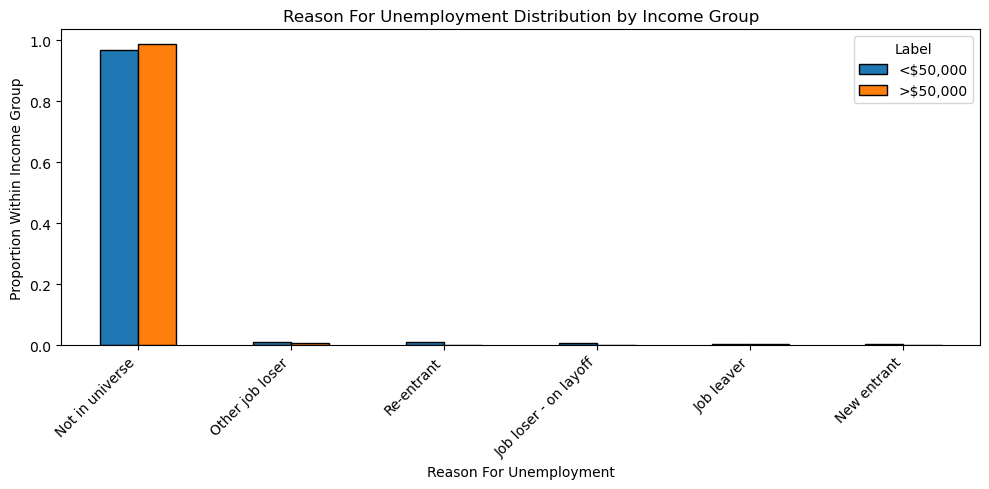

label,"<$50,000",">$50,000"
reason for unemployment,,
Not in universe,0.967930,0.986270
Other job loser,0.010543,0.007995
Re-entrant,0.010848,0.001858
Job loser - on layoff,0.005187,0.001777
Job leaver,0.003121,0.001938
New entrant,0.002371,0.000162


In [100]:
var = 'reason for unemployment'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for region of previous residence:
region of previous residence
Not in universe    180562
South                4875
West                 4068
Midwest              3559
Northeast            2700
Abroad                530
Name: count, dtype: int64

Category percentages for region of previous residence:
region of previous residence
Not in universe    0.919855
South              0.024835
West               0.020724
Midwest            0.018131
Northeast          0.013755
Abroad             0.002700
Name: proportion, dtype: float64

Number of unique categories for region of previous residence: 6



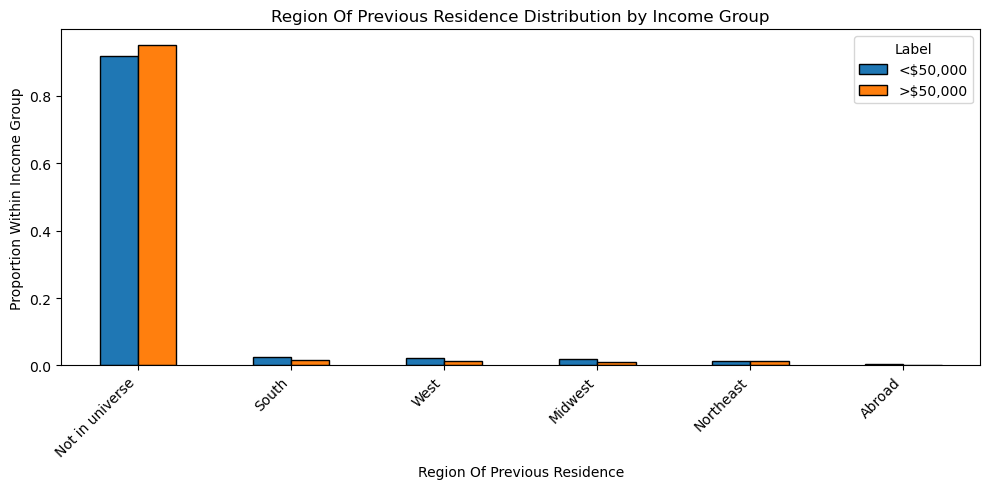

label,"<$50,000",">$50,000"
region of previous residence,,
Not in universe,0.917819,0.950089
South,0.025507,0.014860
West,0.021249,0.012922
Midwest,0.018759,0.008803
Northeast,0.013882,0.011872
Abroad,0.002784,0.001454


In [98]:
var = 'region of previous residence'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for state of previous residence:
state of previous residence
Not in universe         180562
California                1710
Utah                      1061
Florida                    847
North Carolina             810
?                          707
Abroad                     671
Oklahoma                   622
Minnesota                  572
Indiana                    528
North Dakota               497
New Mexico                 462
Michigan                   441
Alaska                     290
Kentucky                   243
Arizona                    243
New Hampshire              242
Wyoming                    241
Colorado                   239
Oregon                     236
West Virginia              231
Georgia                    227
Montana                    226
Alabama                    216
Ohio                       211
Texas                      208
Mississippi                204
Arkansas                   203
Tennessee                  200
Pennsylvania            

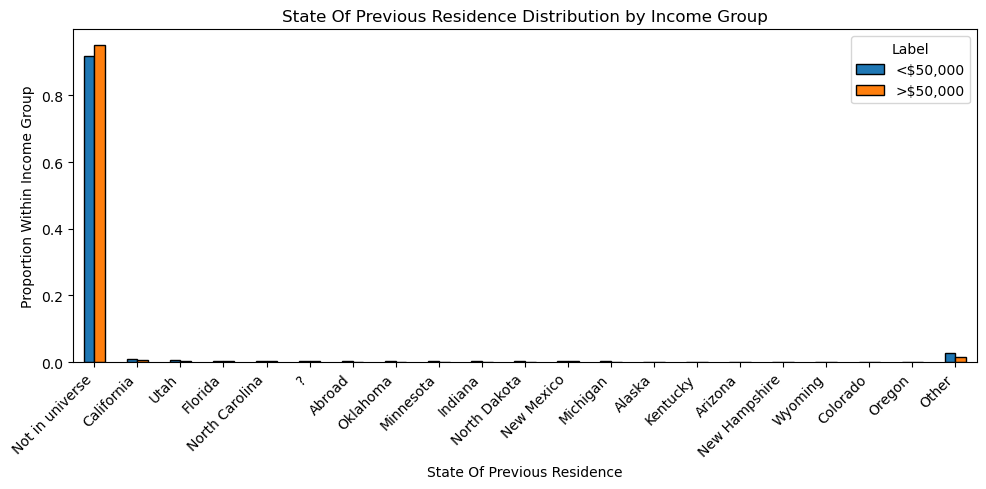

label,"<$50,000",">$50,000"
state of previous residence,,
Not in universe,0.917819,0.950089
California,0.008934,0.005411
Utah,0.005601,0.002504
Florida,0.004442,0.002423
North Carolina,0.004170,0.003473
?,0.003600,0.003634
Abroad,0.003523,0.001858
Oklahoma,0.003273,0.001615
Minnesota,0.003001,0.001615


In [81]:
var = 'state of previous residence'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for migration code-change in msa:
migration code-change in msa
?                   98015
Nonmover            81128
MSA to MSA          10572
NonMSA to nonMSA     2802
Not in universe      1419
MSA to nonMSA         787
NonMSA to MSA         615
Abroad to MSA         453
Not identifiable      430
Abroad to nonMSA       73
Name: count, dtype: int64

Category percentages for migration code-change in msa:
migration code-change in msa
?                   0.499328
Nonmover            0.413298
MSA to MSA          0.053858
NonMSA to nonMSA    0.014275
Not in universe     0.007229
MSA to nonMSA       0.004009
NonMSA to MSA       0.003133
Abroad to MSA       0.002308
Not identifiable    0.002191
Abroad to nonMSA    0.000372
Name: proportion, dtype: float64

Number of unique categories for migration code-change in msa: 10



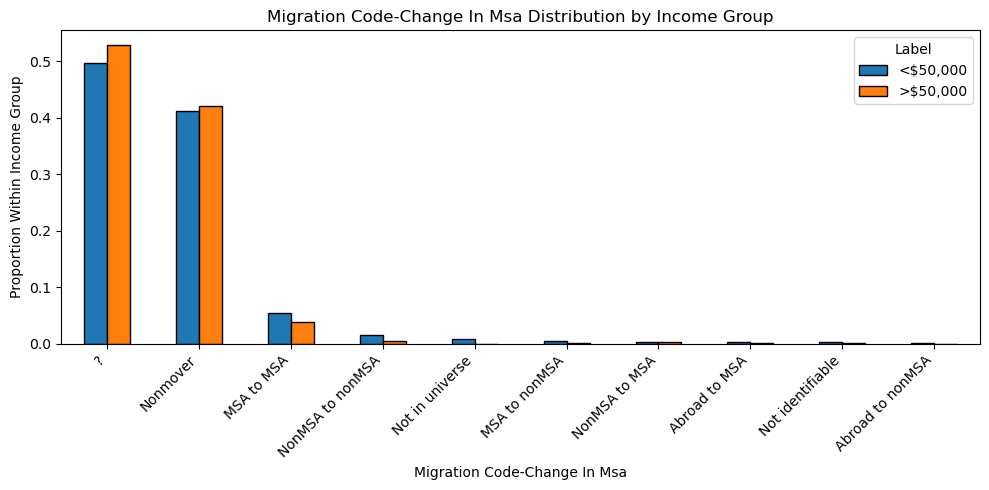

label,"<$50,000",">$50,000"
migration code-change in msa,,
?,0.497368,0.528428
Nonmover,0.412735,0.421660
MSA to MSA,0.054863,0.038927
NonMSA to nonMSA,0.014964,0.004038
Not in universe,0.007716,0.000000
MSA to nonMSA,0.004149,0.001938
NonMSA to MSA,0.003197,0.002181
Abroad to MSA,0.002365,0.001454
Not identifiable,0.002246,0.001373


In [84]:
var = 'migration code-change in msa'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for migration code-change in reg:
migration code-change in reg
?                                 98015
Nonmover                          81128
Same county                        9779
Different county same state        2792
Not in universe                    1419
Different region                   1178
Different state same division       990
Abroad                              530
Different division same region      463
Name: count, dtype: int64

Category percentages for migration code-change in reg:
migration code-change in reg
?                                 0.499328
Nonmover                          0.413298
Same county                       0.049818
Different county same state       0.014224
Not in universe                   0.007229
Different region                  0.006001
Different state same division     0.005043
Abroad                            0.002700
Different division same region    0.002359
Name: proportion, dtype: float64

Number of unique categories f

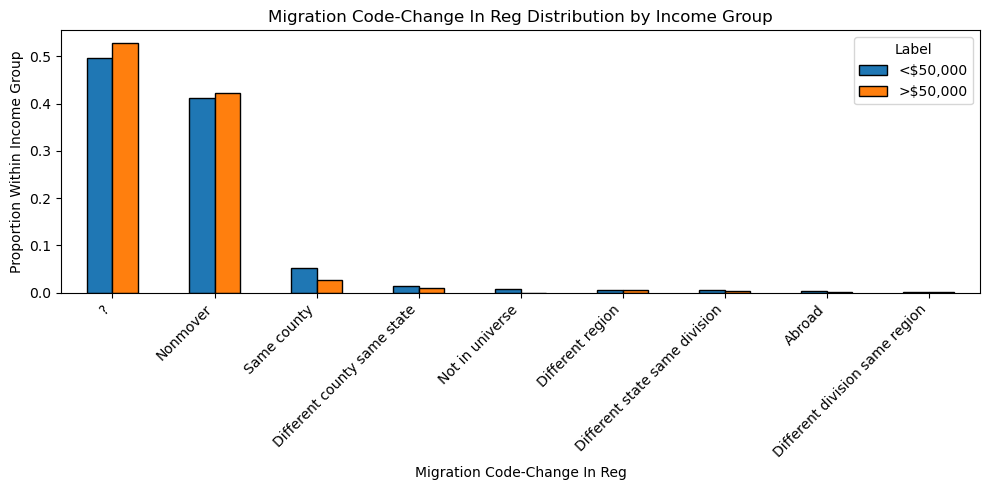

label,"<$50,000",">$50,000"
migration code-change in reg,,
?,0.497368,0.528428
Nonmover,0.412735,0.421660
Same county,0.051389,0.026490
Different county same state,0.014491,0.010257
Not in universe,0.007716,0.000000
Different region,0.005997,0.006057
Different state same division,0.005138,0.003634
Abroad,0.002784,0.001454
Different division same region,0.002382,0.002019


In [85]:
var = 'migration code-change in reg'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for migration code-move within reg:
migration code-move within reg
?                               98015
Nonmover                        81128
Same county                      9779
Different county same state      2792
Not in universe                  1419
Different state in South          972
Different state in West           678
Different state in Midwest        551
Abroad                            530
Different state in Northeast      430
Name: count, dtype: int64

Category percentages for migration code-move within reg:
migration code-move within reg
?                               0.499328
Nonmover                        0.413298
Same county                     0.049818
Different county same state     0.014224
Not in universe                 0.007229
Different state in South        0.004952
Different state in West         0.003454
Different state in Midwest      0.002807
Abroad                          0.002700
Different state in Northeast    0.002191
Name: propor

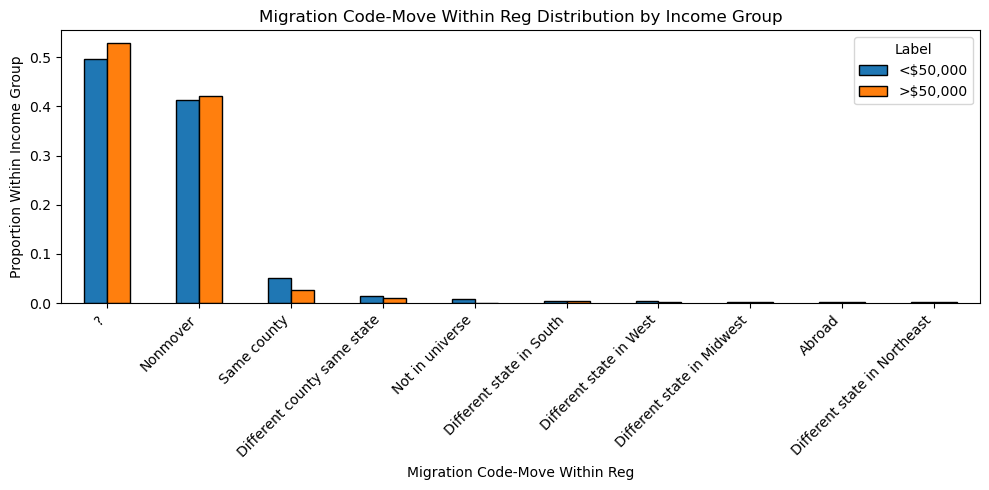

label,"<$50,000",">$50,000"
migration code-move within reg,,
?,0.497368,0.528428
Nonmover,0.412735,0.421660
Same county,0.051389,0.026490
Different county same state,0.014491,0.010257
Not in universe,0.007716,0.000000
Different state in South,0.004953,0.004927
Different state in West,0.003513,0.002584
Different state in Midwest,0.002860,0.002019
Abroad,0.002784,0.001454


In [86]:
var = 'migration code-move within reg'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for live in this house 1 year ago:
live in this house 1 year ago
Not in universe under 1 year old    99434
Yes                                 81128
No                                  15732
Name: count, dtype: int64

Category percentages for live in this house 1 year ago:
live in this house 1 year ago
Not in universe under 1 year old    0.506556
Yes                                 0.413298
No                                  0.080145
Name: proportion, dtype: float64

Number of unique categories for live in this house 1 year ago: 3



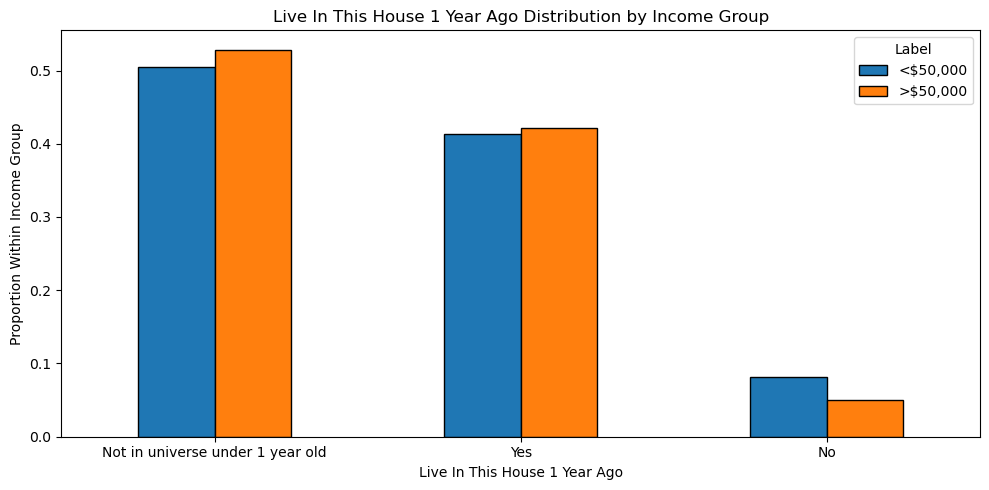

label,"<$50,000",">$50,000"
live in this house 1 year ago,,
Not in universe under 1 year old,0.505084,0.528428
Yes,0.412735,0.421660
No,0.082181,0.049911


In [87]:
var = 'live in this house 1 year ago'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for migration prev res in sunbelt:
migration prev res in sunbelt
?                  98015
Not in universe    82547
No                  9959
Yes                 5773
Name: count, dtype: int64

Category percentages for migration prev res in sunbelt:
migration prev res in sunbelt
?                  0.499328
Not in universe    0.420527
No                 0.050735
Yes                0.029410
Name: proportion, dtype: float64

Number of unique categories for migration prev res in sunbelt: 4



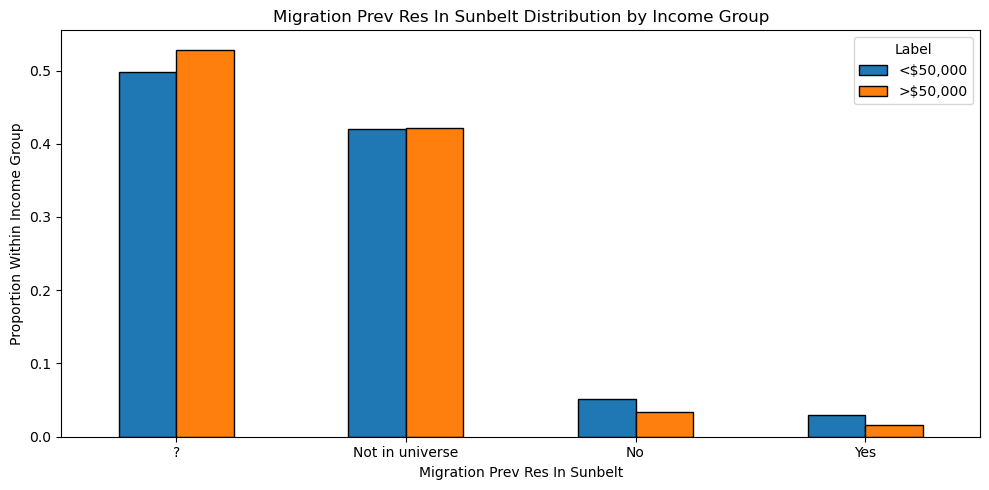

label,"<$50,000",">$50,000"
migration prev res in sunbelt,,
?,0.497368,0.528428
Not in universe,0.420451,0.421660
No,0.051845,0.034243
Yes,0.030335,0.015668


In [88]:
var = 'migration prev res in sunbelt'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for family members under 18:
family members under 18
Not in universe           144161
Both parents present       36107
Mother only present        12517
Father only present         1871
Neither parent present      1638
Name: count, dtype: int64

Category percentages for family members under 18:
family members under 18
Not in universe           0.734414
Both parents present      0.183943
Mother only present       0.063767
Father only present       0.009532
Neither parent present    0.008345
Name: proportion, dtype: float64

Number of unique categories for family members under 18: 5



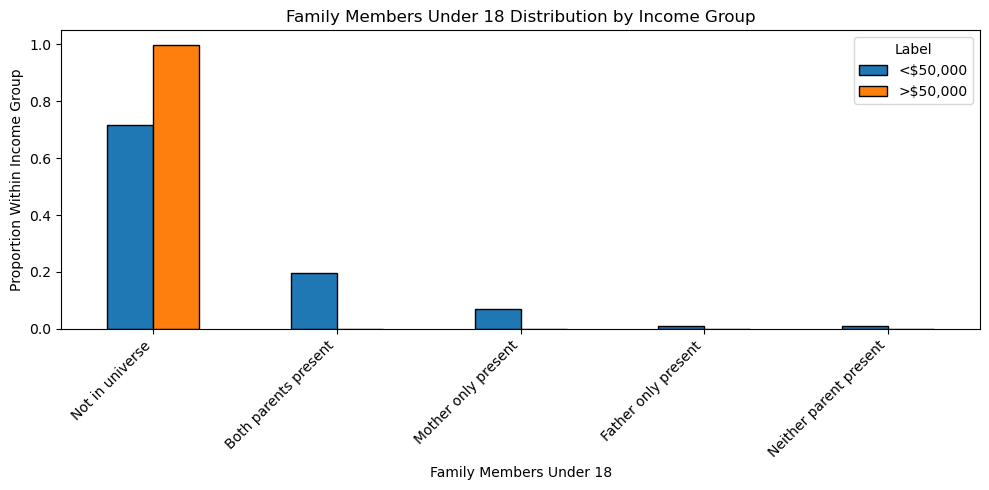

label,"<$50,000",">$50,000"
family members under 18,,
Not in universe,0.716544,0.999838
Both parents present,0.196317,0.000162
Mother only present,0.068060,0.000000
Father only present,0.010173,0.000000
Neither parent present,0.008906,0.000000


In [97]:
var = 'family members under 18'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for country of birth father:
country of birth father
United-States                   156037
Mexico                            9948
?                                 6703
Puerto-Rico                       2676
Italy                             2212
Canada                            1380
Germany                           1356
Dominican-Republic                1284
Poland                            1210
Philippines                       1152
Cuba                              1121
El-Salvador                        982
China                              854
England                            791
Columbia                           614
India                              579
South Korea                        530
Ireland                            508
Jamaica                            461
Vietnam                            457
Guatemala                          443
Japan                              391
Portugal                           387
Ecuador                           

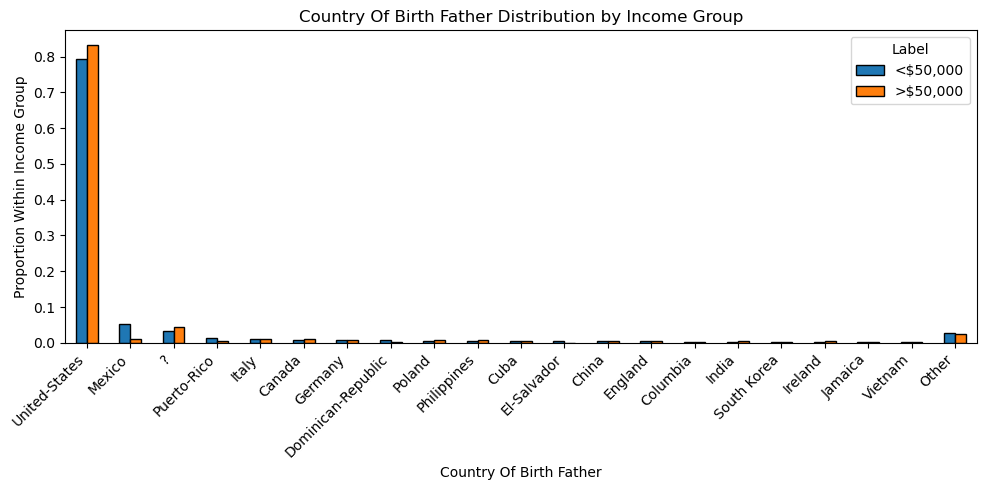

label,"<$50,000",">$50,000"
country of birth father,,
United-States,0.792417,0.832014
Mexico,0.053417,0.010015
?,0.033462,0.044339
Puerto-Rico,0.014192,0.005330
Italy,0.011245,0.011630
Canada,0.006797,0.010499
Germany,0.006775,0.008884
Dominican-Republic,0.006905,0.001131
Poland,0.006025,0.008238


In [90]:
var = 'country of birth father'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for country of birth mother:
country of birth mother
United-States                   157355
Mexico                            9721
?                                 6107
Puerto-Rico                       2468
Italy                             1844
Canada                            1451
Germany                           1382
Philippines                       1228
Poland                            1109
El-Salvador                       1107
Cuba                              1104
Dominican-Republic                1097
England                            901
China                              759
Columbia                           612
South Korea                        607
Ireland                            599
India                              580
Vietnam                            473
Japan                              468
Jamaica                            452
Guatemala                          442
Ecuador                            375
Peru                              

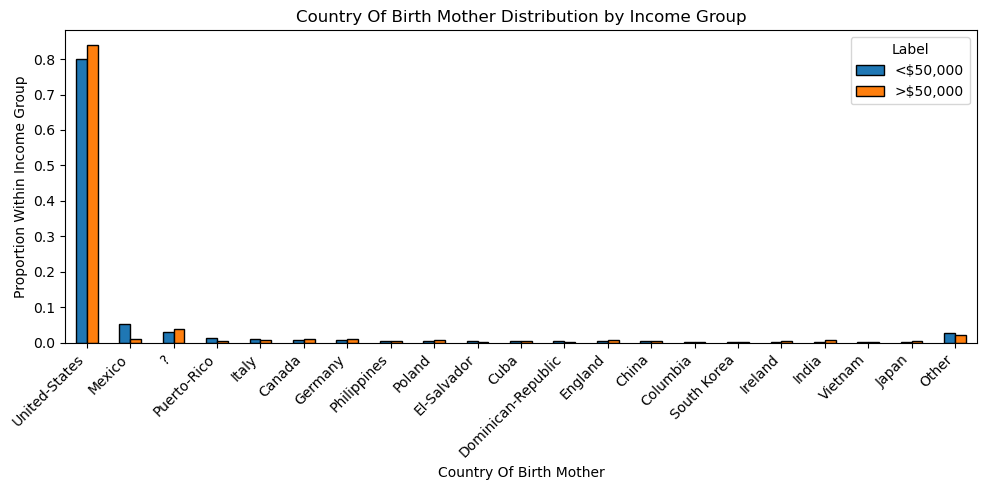

label,"<$50,000",">$50,000"
country of birth mother,,
United-States,0.799116,0.838960
Mexico,0.052117,0.010984
?,0.030656,0.037878
Puerto-Rico,0.013131,0.004280
Italy,0.009466,0.008319
Canada,0.007150,0.010984
Germany,0.006857,0.009772
Philippines,0.006248,0.006380
Poland,0.005508,0.007753


In [91]:
var = 'country of birth mother'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for country of birth self:
country of birth self
United-States                   173783
Mexico                            5759
?                                 3389
Puerto-Rico                       1400
Germany                            850
Philippines                        844
Cuba                               836
Canada                             700
El-Salvador                        689
Dominican-Republic                 687
China                              478
South Korea                        471
England                            455
Columbia                           434
Italy                              419
India                              407
Vietnam                            391
Poland                             381
Guatemala                          343
Japan                              339
Jamaica                            320
Peru                               268
Ecuador                            258
Haiti                              228

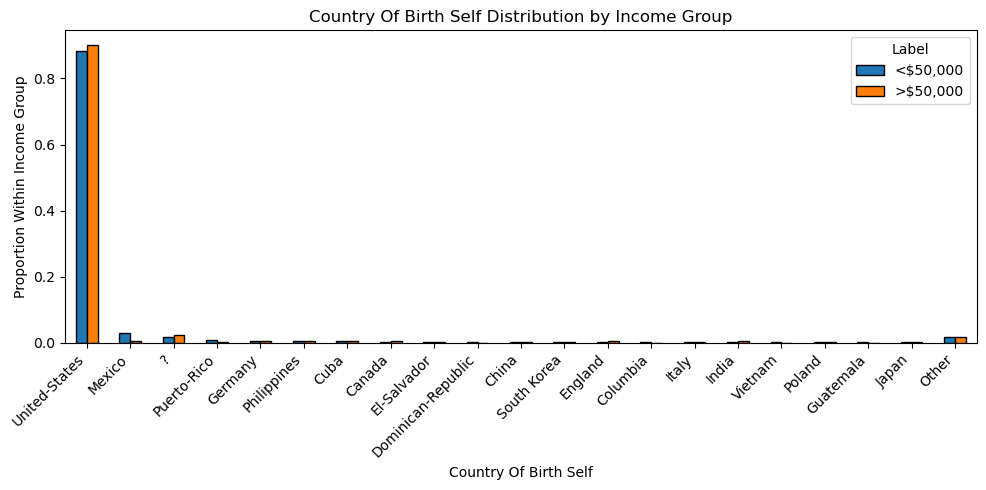

label,"<$50,000",">$50,000"
country of birth self,,
United-States,0.884303,0.900420
Mexico,0.030906,0.006057
?,0.016812,0.023986
Puerto-Rico,0.007449,0.002423
Germany,0.004230,0.005815
Philippines,0.004165,0.006299
Cuba,0.004219,0.004846
Canada,0.003431,0.005573
El-Salvador,0.003676,0.001050


In [92]:
var = 'country of birth self'
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)

Category counts for fill inc questionnaire for veteran's admin:
fill inc questionnaire for veteran's admin
Not in universe    194310
No                   1593
Yes                   391
Name: count, dtype: int64

Category percentages for fill inc questionnaire for veteran's admin:
fill inc questionnaire for veteran's admin
Not in universe    0.989893
No                 0.008115
Yes                0.001992
Name: proportion, dtype: float64

Number of unique categories for fill inc questionnaire for veteran's admin: 3



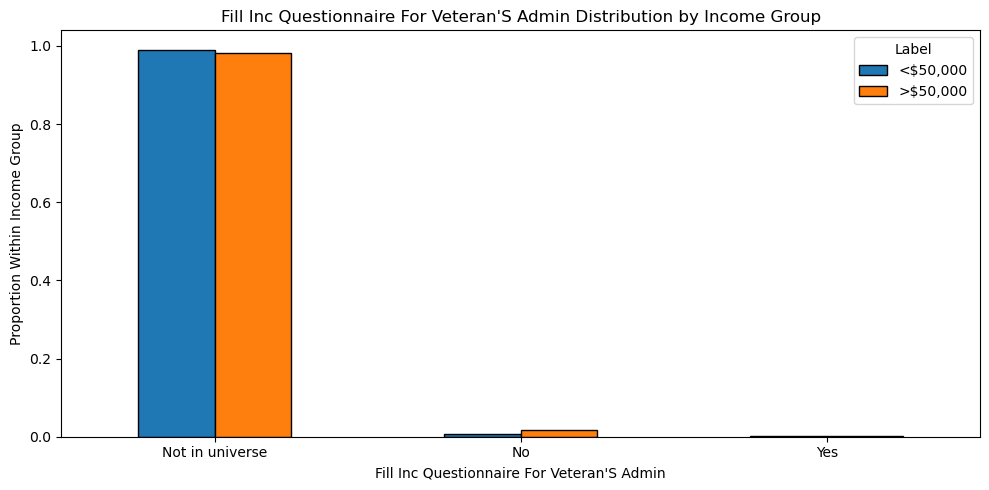

label,"<$50,000",">$50,000"
fill inc questionnaire for veteran's admin,,
Not in universe,0.990468,0.981344
No,0.007493,0.017364
Yes,0.002039,0.001292


In [94]:
var = "fill inc questionnaire for veteran's admin"
categorical_feature_analysis(raw_data, var)
plot_categorical_by_label(raw_data, var, top_n=20)